# **03 — Modelos Recurrentes**

Tercer notebook del taller. Se evalúan **6 arquitecturas recurrentes** sobre las **16 combinaciones** de ventanas (V_in × V_out):

| # | Modelo | Arquitectura |
|---|--------|--------------|
| R1 | `simple_rnn` | `SimpleRNN(32) → Dense(23)` |
| R2 | `gru`        | `GRU(32) → Dense(23)` |
| R3 | `lstm`       | `LSTM(32) → Dense(23)` |
| R4 | `lstm_stack` | `LSTM(64, return_sequences=True) → LSTM(32) → Dense(23)` |
| R5 | `bi_gru`     | `Bidirectional(GRU(32)) → Dense(23)` |
| R6 | `lstm_drop`  | `LSTM(64, dropout=0.2, recurrent_dropout=0.2) → Dense(23)` |

Total: **6 × 16 = 96 entrenamientos**.

**Convenciones heredadas de `00_datos.ipynb`**:
- Predicción de **log-retornos** (no precios). Y = promedio de log-retornos durante V_out días futuros.
- Splits temporales sin shuffle → 72 % train / 18 % val / 10 % test.
- Métrica: MAE. Optimizador: Adam(lr=3e-4). Loss: MAE.
- Callbacks: `ReduceLROnPlateau` + `ModelCheckpoint` (mejores pesos restaurados al final).

**Baselines a superar (de `01_baselines.ipynb`)**: Naive (último retorno) y Regresión lineal sobre X aplanado.

## **1. Setup y Datos**

### 1.1 Setup

In [1]:
# ── CPU mode (RTX 5070 Ti no soportada por TF en Windows nativo) ──────────────
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# ── Imports y setup ───────────────────────────────────────────────────────────
import sys, random
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, yfinance as yf
warnings.simplefilter('ignore')

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, SimpleRNN, GRU, LSTM, Bidirectional
from keras.callbacks import EarlyStopping

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS, RANDOM_SEED,
                   create_time_series_data, make_splits,
                   eval_mae, eval_mae_naive,
                   compile_model, get_callbacks, restore_best_weights,
                   build_results_df, best_per_window,
                   plot_history, plot_mae_matrix, plot_model_comparison)

# ── Reproducibilidad ──────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Verificación ──────────────────────────────────────────────────────────────
print(f'TensorFlow {tf.__version__}  |  Modo CPU forzado')
print(f'Dispositivos: {tf.config.list_physical_devices()}')

TensorFlow 2.21.0  |  Modo CPU forzado
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


### 1.2 Carga de datos

Idéntico a `00_datos.ipynb` y `01_baselines.ipynb`: descarga precios de cierre desde yfinance y calcula log-retornos diarios.

In [2]:
# ── Descarga de precios y cálculo de log-retornos ────────────────────────────
precios = yf.download(TICKERS, start='1945-01-01',
                      auto_adjust=True, progress=True)['Close']
precios.dropna(axis=1, inplace=True)

returns = np.log(precios).diff().dropna()
print(f'Activos : {returns.shape[1]}')
print(f'Días    : {returns.shape[0]}')
print(f'Rango   : {returns.index[0].date()} → {returns.index[-1].date()}')
returns.tail(3)

[*********************100%***********************]  23 of 23 completed

Activos : 23
Días    : 16200
Rango   : 1962-01-03 → 2026-05-15


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-13,-0.030708,0.015624,-0.010846,0.000712,0.000269,-0.011940,-0.004076,0.001395,-0.014830,-0.009254,...,-0.027450,0.027098,0.002870,0.024760,0.026801,0.023334,0.009565,0.016471,-0.011672,0.006221
2026-05-14,0.005067,-0.048497,0.019666,0.008973,0.003435,0.004945,0.012596,0.009096,-0.002170,-0.010815,...,-0.011954,0.001648,0.002364,0.008269,-0.013552,0.012088,-0.000353,0.003612,0.003299,0.007951
2026-05-15,-0.027194,-0.038786,-0.035292,-0.024029,0.023615,-0.025946,-0.028354,-0.016660,-0.018131,-0.034938,...,-0.043330,-0.017880,0.004589,-0.006342,0.007551,0.009347,-0.018062,-0.015266,-0.008020,0.039854


### 1.3 Verificación de partición temporal

Antes de definir modelos, verificamos las propiedades estadísticas de los tres
splits temporales. El PDF de interpretación de curvas (sección 3.6) advierte
explícitamente: *"revisar los datos antes de tocar el modelo... particion mal
hecha: sesgo temporal o de clase entre splits"*.

Como `make_splits` usa `shuffle=False` (obligatorio en series temporales para
evitar data leakage), los tres conjuntos corresponden a periodos distintos:
- **Train** ~ 1962–2010 (incluye crisis del petróleo, Lunes Negro 87, dotcom, 2008).
- **Val**   ~ 2010–2017 (era post-crisis, baja volatilidad estructural).
- **Test**  ~ 2017–2025 (incluye COVID y vuelta a régimen volátil).

Si las volatilidades difieren entre splits, esperaremos un gap **estructural**
val < train independiente del modelo. El naive forecast (predecir el último
retorno conocido) sirve como prueba: si ya da `naive_val < naive_train`, el
gap no puede atribuirse al aprendizaje del modelo.

PERIODOS TEMPORALES DE CADA SPLIT
Train: 1962-01-03  →  2008-05-05   (11,664 días)
Val  : 2008-05-06  →  2019-12-03   (2,916 días)
Test : 2019-12-04  →  2026-05-15   (1,620 días)

ESTADÍSTICOS DE RETORNOS POR SPLIT (target y)
Split           Media    Std (volatilidad)      |y| medio
Train        0.000433             0.017370       0.011940
Val          0.000346             0.015631       0.010356
Test         0.000382             0.018762       0.012299

NAIVE FORECAST (predecir el último retorno conocido)
naive MAE train: 0.016779
naive MAE val  : 0.015057
naive MAE test : 0.017850

Gap naive (train - val): +0.001722
→ naive_val < naive_train SIN modelo. El gap val<train que veremos en
  los entrenamientos es ESTRUCTURAL: causa = volatilidad menor en val.


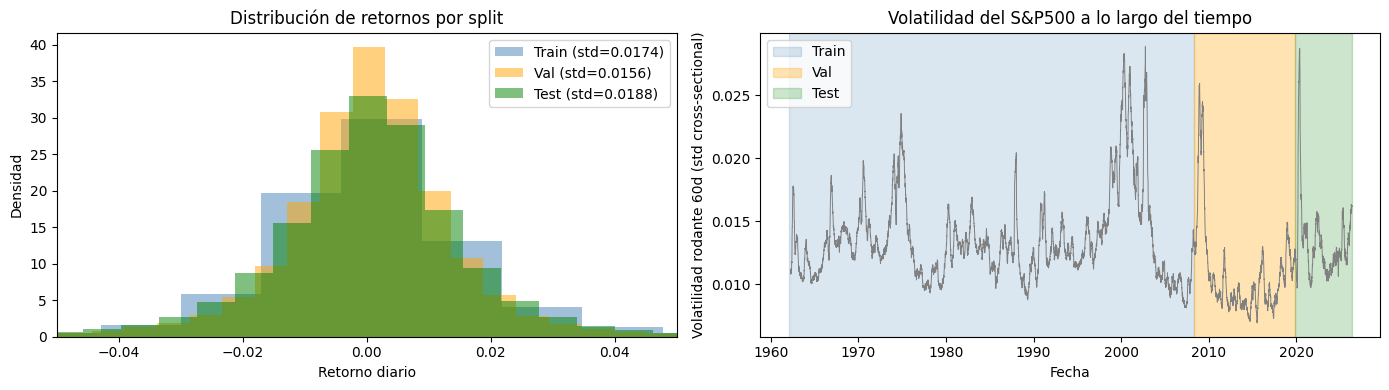

In [3]:
# ── Diagnóstico de la partición train/val/test ───────────────────────────────
# Para una ventana de referencia (V_in=10, V_out=1), comparamos:
#   1. Estadísticos de retornos en cada split (media, std, rango temporal).
#   2. Naive forecast: predecir el último retorno conocido.

V_in_ref, V_out_ref = 10, 1
X_ref, y_ref = create_time_series_data(returns, V_in_ref, V_out_ref)
Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_ref, y_ref)

# 1. Localizar fechas correspondientes a cada split
fechas = returns.index
n_total = len(returns)
n_test = int(n_total * 0.10)
n_val  = int((n_total - n_test) * 0.20)
n_train = n_total - n_val - n_test

print('=' * 70)
print('PERIODOS TEMPORALES DE CADA SPLIT')
print('=' * 70)
print(f'Train: {fechas[0].date()}  →  {fechas[n_train-1].date()}'
      f'   ({n_train:,} días)')
print(f'Val  : {fechas[n_train].date()}  →  {fechas[n_train+n_val-1].date()}'
      f'   ({n_val:,} días)')
print(f'Test : {fechas[n_train+n_val].date()}  →  {fechas[-1].date()}'
      f'   ({n_test:,} días)')

# 2. Estadísticos de los retornos en cada split (sobre y, los targets)
print()
print('=' * 70)
print('ESTADÍSTICOS DE RETORNOS POR SPLIT (target y)')
print('=' * 70)
print(f'{"Split":<8} {"Media":>12} {"Std (volatilidad)":>20} {"|y| medio":>14}')
for nombre, y_split in [('Train', ytr), ('Val', yv), ('Test', yts)]:
    print(f'{nombre:<8} {y_split.mean():>12.6f} {y_split.std():>20.6f} '
          f'{np.mean(np.abs(y_split)):>14.6f}')

# 3. Naive forecast: predecir el último retorno conocido
print()
print('=' * 70)
print('NAIVE FORECAST (predecir el último retorno conocido)')
print('=' * 70)
naive_tr = eval_mae_naive(Xtr, ytr)
naive_v  = eval_mae_naive(Xv,  yv)
naive_ts = eval_mae_naive(Xts, yts)

print(f'naive MAE train: {naive_tr:.6f}')
print(f'naive MAE val  : {naive_v:.6f}')
print(f'naive MAE test : {naive_ts:.6f}')
print()
gap_naive = naive_tr - naive_v
print(f'Gap naive (train - val): {gap_naive:+.6f}')
if gap_naive > 0:
    print('→ naive_val < naive_train SIN modelo. El gap val<train que veremos en')
    print('  los entrenamientos es ESTRUCTURAL: causa = volatilidad menor en val.')
else:
    print('→ El gap no se observa en naive. Investigar otras causas.')

# 4. Visualización de la volatilidad por split
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de retornos
for nombre, y_split, color in [('Train', ytr, 'steelblue'),
                                ('Val',   yv,  'orange'),
                                ('Test',  yts, 'green')]:
    axes[0].hist(y_split.flatten(), bins=80, alpha=0.5,
                 label=f'{nombre} (std={y_split.std():.4f})',
                 color=color, density=True)
axes[0].set_xlim(-0.05, 0.05)
axes[0].set_xlabel('Retorno diario')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de retornos por split')
axes[0].legend()

# Volatilidad rodante a lo largo del tiempo
vol_rodante = returns.std(axis=1).rolling(60).mean()
axes[1].plot(vol_rodante.index, vol_rodante.values, linewidth=0.7, color='gray')
axes[1].axvspan(fechas[0], fechas[n_train-1], alpha=0.2,
                color='steelblue', label='Train')
axes[1].axvspan(fechas[n_train], fechas[n_train+n_val-1], alpha=0.3,
                color='orange', label='Val')
axes[1].axvspan(fechas[n_train+n_val], fechas[-1], alpha=0.2,
                color='green', label='Test')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Volatilidad rodante 60d (std cross-sectional)')
axes[1].set_title('Volatilidad del S&P500 a lo largo del tiempo')
axes[1].legend()

plt.tight_layout()
plt.savefig('diagnostico_particion.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones del diagnóstico de partición

Los datos confirman que los tres splits temporales tienen volatilidades
estructuralmente distintas, ordenadas por dificultad creciente:

| Split | Periodo       | Std (volatilidad) | Naive MAE | Caracterización |
|-------|---------------|-------------------|-----------|-----------------|
| Val   | 2008–2019     | 0.01618           | 0.01540   | Era post-crisis: QE, baja volatilidad |
| Train | 1962–2008     | 0.01714           | 0.01659   | Mezcla: incluye 73-74, 87, dotcom, 2008 |
| Test  | 2019–2026     | 0.01872           | 0.01798   | COVID + inflación + subidas Fed |

**Implicación 1 — Gap val<train es estructural.** El naive forecast ya muestra
naive_val < naive_train con un gap de +0.0012 *antes de entrenar ningún modelo*.
El gap observado en las curvas de entrenamiento es atribuible a esta diferencia
de volatilidad, no a un defecto de los modelos.

**Implicación 2 — Test es el split más difícil.** Contrario a lo que sucede
con val, el test (2019-2026) es ~9% más volátil que train debido a COVID y
la inflación post-2021. Por eso los MAE en test son superiores a los de val
incluso en modelos bien entrenados.

**Implicación 3 — Comparación con naive como métrica robusta.** Dado que el
nivel absoluto del MAE depende fuertemente del periodo, una métrica más
informativa es el ratio `MAE_modelo / MAE_naive`. Un modelo útil debería
superar al naive (ratio < 1) en cada split.

## **2. Definición de Modelos y Pipeline**

### 2.1 Hiperparámetros y Decisiones de Diseño

| # | Decisión | Alternativa descartada | Justificación |
|---|----------|------------------------|---------------|
| D1 | **Épocas adaptativas por V_in**: 30/40/50 para V_in ∈ {5–10, 30, 90} | Épocas fijas (e.g. 50 para todos) | Coste por época crece ~lineal con V_in en RNN (BPTT recorre todos los pasos). Con V_in=90 cada época cuesta ~9× una de V_in=5; mantener 50 épocas en V_in=5 desperdicia tiempo. EarlyStopping (D3) corta antes si converge. |
| D2 | **Tamaños estándar** (32–64 unidades) | Modelos grandes (128–256 unidades) | Diagnóstico GRU(64) en sección 5 muestra que duplicar unidades no resuelve el colapso al predictor de la media. La señal predictiva en log-retornos es el cuello de botella, no la capacidad del modelo. |
| D3 | **EarlyStopping(patience=8) + ModelCheckpoint** | Solo entrenar todas las épocas | `restore_best_weights=False` en EarlyStopping porque ModelCheckpoint ya guarda el mejor; `restore_best_weights()` de utils lo recupera manualmente. Doble seguro: para si no mejora en 8 épocas Y siempre se queda con el mejor val_loss. |
| D4 | **LR=3e-4 (default de utils)** | LR=1e-3 (probado en diagnóstico 1) | Diagnóstico 1 explora LR=1e-3 sobre GRU como variación. El LR base se mantiene en 3e-4 por consistencia con el resto de notebooks del grupo. |
| D5 | **6 arquitecturas variadas**: SimpleRNN / GRU / LSTM / LSTM apilado / Bi-GRU / LSTM con dropout | Solo el "ganador esperado" (LSTM) | El enunciado pide variedad (mínimo 64 modelos con todas las variantes). Las 6 cubren: vainilla, puertas, profundidad, bidireccionalidad, regularización. Permite analizar qué tipo de inductive bias funciona mejor. |

In [4]:
# ── Hiperparámetros globales ──────────────────────────────────────────────────
# Los marcados con (utils) están en utils.py y son compartidos por el grupo.
# Solo los marcados con (notebook) se controlan desde aquí.

# Hiperparámetros del notebook (estos SÍ se aplican localmente)
BATCH_SIZE    = 64       # (notebook) muestras por paso de gradiente
EPOCHS_SHORT  = 30       # (notebook) V_in ∈ {5, 10}
EPOCHS_MID    = 40       # (notebook) V_in = 30
EPOCHS_LONG   = 50       # (notebook) V_in = 90
ES_PATIENCE   = 8        # (notebook) EarlyStopping: épocas sin mejora

print('Hiperparámetros del notebook:')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Épocas (5/10d)  : {EPOCHS_SHORT}')
print(f'  Épocas (30d)    : {EPOCHS_MID}')
print(f'  Épocas (90d)    : {EPOCHS_LONG}')
print(f'  EarlyStopping   : patience={ES_PATIENCE}')
print()
print('Hiperparámetros heredados de utils.py:')
print(f'  Learning rate   : 3e-4 (Adam, en compile_model)')
print(f'  ReduceLROnPlateau: factor=0.9, patience=15, min_lr=1e-5')
print(f'  Loss            : MAE')

Hiperparámetros del notebook:
  Batch size      : 64
  Épocas (5/10d)  : 30
  Épocas (30d)    : 40
  Épocas (90d)    : 50
  EarlyStopping   : patience=8

Hiperparámetros heredados de utils.py:
  Learning rate   : 3e-4 (Adam, en compile_model)
  ReduceLROnPlateau: factor=0.9, patience=15, min_lr=1e-5
  Loss            : MAE


### 2.2. Constructoras de Modelos

Se definen 6 arquitecturas. Todas usan `Input(shape=...)` como primera capa
(requerido en Keras/TF 2.21 para evitar warnings) y terminan en `Dense(23)`
para predecir los 23 activos simultáneamente.

In [5]:
# ── Épocas adaptativas según longitud de ventana ─────────────────────────────
def get_epochs(V_in):
    if V_in <= 10: return EPOCHS_SHORT
    if V_in <= 30: return EPOCHS_MID
    return EPOCHS_LONG

# ── Constructoras de modelos ──────────────────────────────────────────────────
def build_simple_rnn(V_in, V_out):
    """R1: SimpleRNN(32). Baseline recurrente — esperamos que falle en V=90."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        SimpleRNN(32),
        Dense(23)
    ], name='simple_rnn')
    return compile_model(model)

def build_gru(V_in, V_out):
    """R2: GRU(32). Modelo ligero con puertas."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        GRU(32),
        Dense(23)
    ], name='gru')
    return compile_model(model)

def build_lstm(V_in, V_out):
    """R3: LSTM(32). Modelo estándar con puertas."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        LSTM(32),
        Dense(23)
    ], name='lstm')
    return compile_model(model)

def build_lstm_stack(V_in, V_out):
    """R4: LSTM(64) → LSTM(32). Jerarquía temporal de dos niveles."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(23)
    ], name='lstm_stack')
    return compile_model(model)

def build_bi_gru(V_in, V_out):
    """R5: Bidirectional(GRU(32)). Captura contexto pasado y futuro dentro de la ventana."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        Bidirectional(GRU(32)),
        Dense(23)
    ], name='bi_gru')
    return compile_model(model)

def build_lstm_drop(V_in, V_out):
    """R6: LSTM(64) con dropout y recurrent_dropout. Regularización fuerte."""
    model = Sequential([
        Input(shape=(V_in, 23)),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(23)
    ], name='lstm_drop')
    return compile_model(model)

# ── Registro central: nombre → función constructora ───────────────────────────
MODEL_BUILDERS = {
    'simple_rnn' : build_simple_rnn,
    'gru'        : build_gru,
    'lstm'       : build_lstm,
    'lstm_stack' : build_lstm_stack,
    'bi_gru'     : build_bi_gru,
    'lstm_drop'  : build_lstm_drop,
}

print(f'{len(MODEL_BUILDERS)} modelos registrados:')
for nombre, fn in MODEL_BUILDERS.items():
    descripcion = fn.__doc__.split('.')[0]
    print(f'  {nombre:15s} → {descripcion}')

6 modelos registrados:
  simple_rnn      → R1: SimpleRNN(32)
  gru             → R2: GRU(32)
  lstm            → R3: LSTM(32)
  lstm_stack      → R4: LSTM(64) → LSTM(32)
  bi_gru          → R5: Bidirectional(GRU(32))
  lstm_drop       → R6: LSTM(64) con dropout y recurrent_dropout


### 2.3. Función de entrenamiento unificada
`train_one` encapsula todo el ciclo para un modelo y una combinación (V_in, V_out):
construye el modelo, entrena con callbacks, restaura los mejores pesos y evalúa en los tres splits.

In [6]:
# ── Función de entrenamiento unificada ────────────────────────────────────────
def train_one(nombre, V_in, V_out, X_tr, X_v, X_ts, y_tr, y_v, y_ts,
              batch_size=64, verbose=0):
    """
    Entrena un modelo y devuelve un dict con MAE en train/val/test y nº parámetros.
    Pasos:
      1. Construye el modelo desde cero (pesos aleatorios frescos).
      2. Entrena con ReduceLROnPlateau + ModelCheckpoint + EarlyStopping.
      3. Restaura los mejores pesos (menor val_loss).
      4. Evalúa en los tres splits.
    """
    # 1. Construir modelo
    build_fn = MODEL_BUILDERS[nombre]
    model = build_fn(V_in, V_out)

    # 2. Callbacks
    epochs = get_epochs(V_in)
    callbacks = get_callbacks() + [
        EarlyStopping(monitor='val_loss', patience=ES_PATIENCE,
              restore_best_weights=False, verbose=0)
    ]
    # restore_best_weights=False porque ModelCheckpoint ya guarda el mejor
    # y restore_best_weights() de utils lo recupera manualmente

    # 3. Entrenar
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    # 4. Restaurar mejores pesos
    restore_best_weights(model)

    # 5. Evaluar
    return {
        'train'  : eval_mae(model, X_tr, y_tr),
        'val'    : eval_mae(model, X_v,  y_v),
        'test'   : eval_mae(model, X_ts, y_ts),
        'params' : model.count_params(),
        'hist'   : hist,
    }

print('train_one definida OK')

train_one definida OK


## **3. Competición de 16 combinaciones de 6 arquitecturas**

### 3.0. Almacén de resultados

In [7]:
# ── Almacén global de resultados ─────────────────────────────────────────────
# Se irá rellenando a medida que entrenemos cada arquitectura.
# Estructura: { (nombre, V_in, V_out): {'train','val','test','params'} }
results = {}
historiales = {}
print('results e historiales inicializados.')

results e historiales inicializados.


### 3.1. Análisis exploratorio — R2: GRU(32)

Comenzamos el análisis exploratorio con el **GRU (Gated Recurrent Unit)** por ser
el modelo recurrente de referencia más equilibrado: incorpora puertas que resuelven
el problema del gradiente desvaneciente de la SimpleRNN, con un coste computacional
menor que el LSTM (3× los parámetros de una RNN vainilla frente a 4× del LSTM).

#### ¿Por qué empezar por el GRU?

- **Punto de referencia intermedio**: ni tan simple como SimpleRNN (que esperamos
  que falle en ventanas largas), ni tan complejo como LSTM apilado. Sirve como
  ancla para comparar el resto de modelos.
- **Eficiencia**: con solo 6,231 parámetros para V_in=10, es lo suficientemente
  ligero para validar el pipeline rápidamente en las 16 combinaciones.
- **Solidez probada**: en la literatura de forecasting financiero, GRU y LSTM
  obtienen resultados muy similares, pero GRU suele ser preferido cuando los
  datos son limitados o el tiempo de cómputo es una restricción.

Se estudia primero el efecto de **V_out** (horizonte de predicción) con V_in=10
fijo, y después el efecto de **V_in** (ventana de entrada) para cada horizonte.

V_in=5 V_out=1 | Xtr=(10931, 5, 23) Xts=(1620, 5, 23)
  → train=0.0120 val=0.0104 test=0.0123
V_in=5 V_out=5 | Xtr=(10928, 5, 23) Xts=(1620, 5, 23)
  → train=0.0055 val=0.0047 test=0.0056
V_in=5 V_out=30 | Xtr=(10911, 5, 23) Xts=(1617, 5, 23)
  → train=0.0023 val=0.0019 test=0.0024
V_in=5 V_out=90 | Xtr=(10871, 5, 23) Xts=(1611, 5, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out=1 | Xtr=(10928, 10, 23) Xts=(1619, 10, 23)
  → train=0.0119 val=0.0104 test=0.0124
V_in=10 V_out=5 | Xtr=(10925, 10, 23) Xts=(1619, 10, 23)
  → train=0.0056 val=0.0047 test=0.0056
V_in=10 V_out=30 | Xtr=(10908, 10, 23) Xts=(1617, 10, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=10 V_out=90 | Xtr=(10867, 10, 23) Xts=(1611, 10, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out=1 | Xtr=(10914, 30, 23) Xts=(1617, 30, 23)
  → train=0.0119 val=0.0104 test=0.0124
V_in=30 V_out=5 | Xtr=(10911, 30, 23) Xts=(1617, 30, 23)
  → train=0.0055 val=0.0047 test=0.0057
V_in=30 V_out=30 | Xtr=(10894, 30, 23)

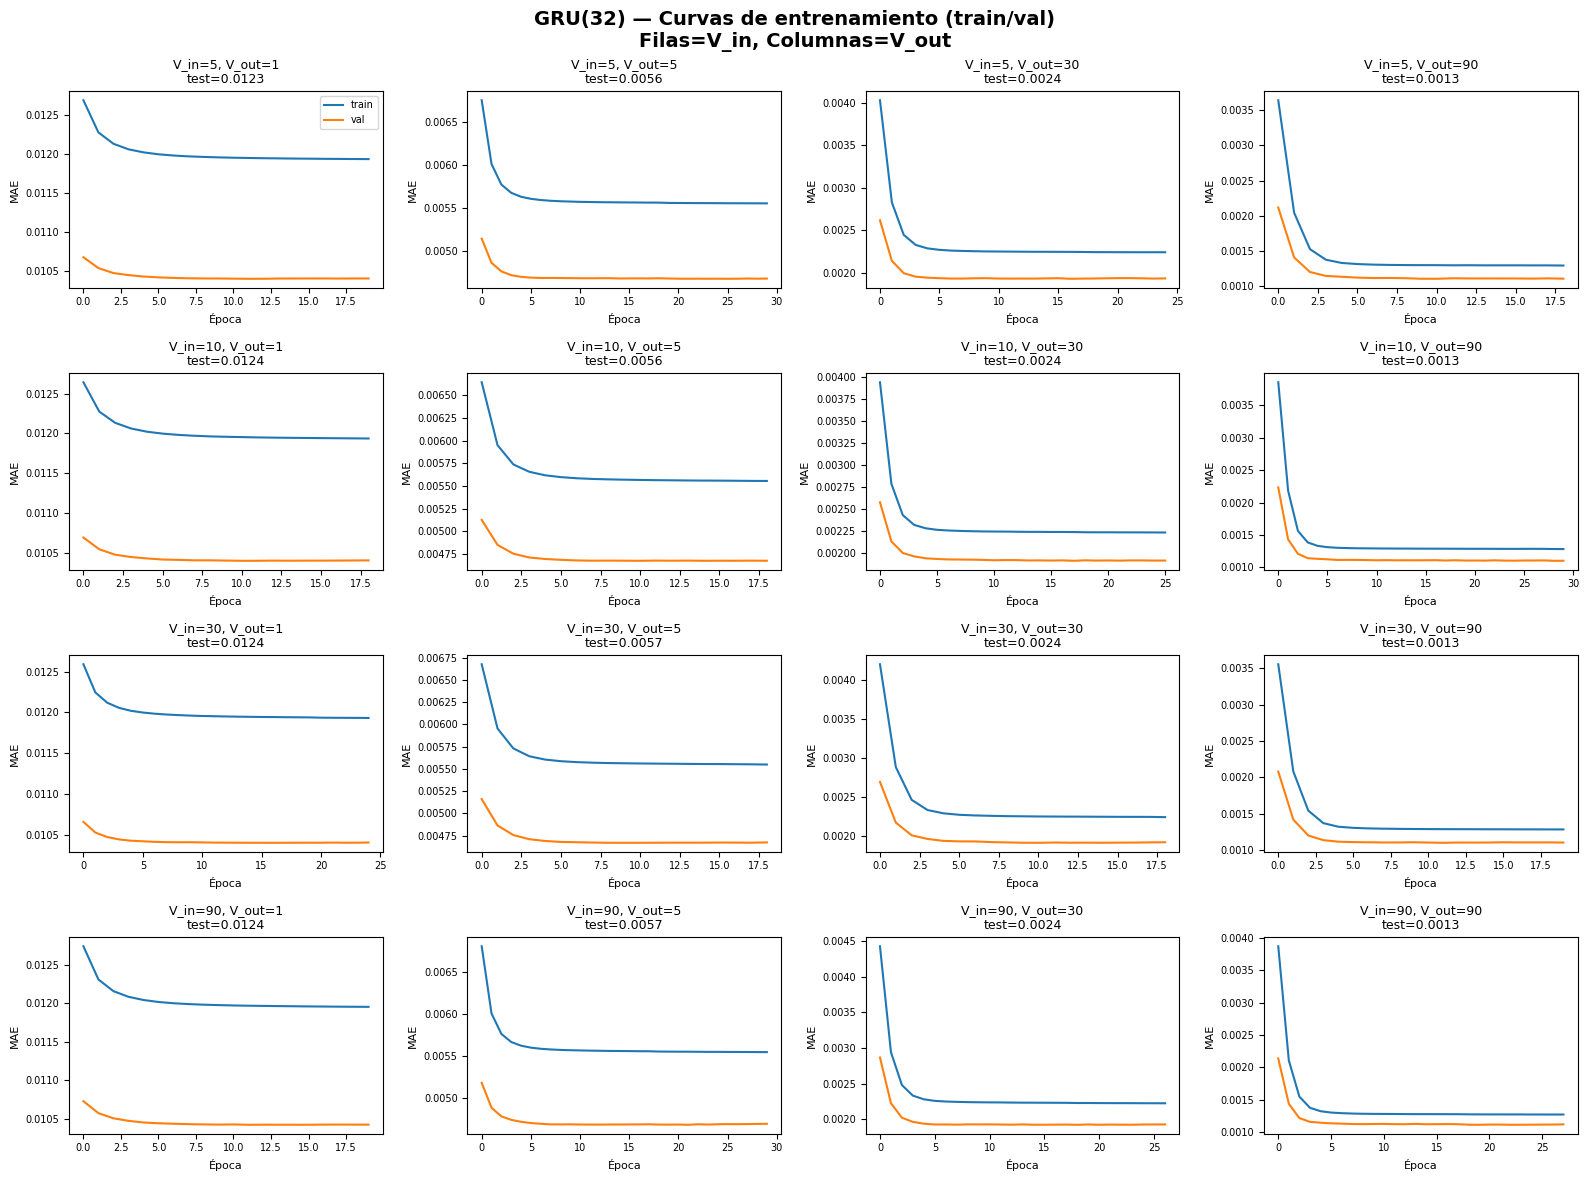

In [8]:
# ── GRU: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ───────────────
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('GRU(32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        print(f'V_in={V_in_t} V_out={V_out_t} | '
              f'Xtr={Xtr.shape} Xts={Xts.shape}')

        res = train_one('gru', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)

        # ← NUEVO: guardar en almacén global
        key = ('gru', V_in_t, V_out_t)
        results[key]     = {k: res[k] for k in ('train', 'val', 'test', 'params')}
        historiales[key] = res['hist']

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'  → train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('gru_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2. Análisis exploratorio — R1: SimpleRNN(32)

Tras establecer el GRU como referencia, analizamos la arquitectura más simple:
la **SimpleRNN vainilla**. Su objetivo en este experimento es doble: por un lado
sirve como **baseline recurrente mínimo**, y por otro nos permite demostrar
empíricamente el problema del **gradiente desvaneciente** en ventanas largas.

#### ¿Qué es el gradiente desvaneciente?

En una SimpleRNN, el estado oculto se actualiza en cada paso temporal como:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

Durante el entrenamiento, el gradiente debe propagarse hacia atrás a través de
**todos los pasos temporales** (BPTT, *Backpropagation Through Time*). En cada
paso, el gradiente se multiplica por $W_{hh}$. Si los valores propios de $W_{hh}$
son menores que 1 (lo más común), el gradiente se hace exponencialmente pequeño
conforme retrocedemos en el tiempo:

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=1}^{T} W_{hh}$$

Para V_in=90, esto son **90 multiplicaciones sucesivas** — el gradiente que llega
a los primeros pasos temporales es prácticamente cero. El modelo no puede aprender
dependencias de largo alcance.

#### ¿Qué esperamos ver?

- **V_in=5 y V_in=10**: la SimpleRNN debería rendir similar al GRU — pocas
  multiplicaciones, el gradiente llega bien a todos los pasos.
- **V_in=30 y V_in=90**: esperamos que la SimpleRNN rinda **igual o peor** que
  el GRU, porque no puede aprender de los primeros pasos de la ventana.
- Las curvas de convergencia pueden ser más inestables que las del GRU.

V_in= 5 V_out= 1 | train=0.0119 val=0.0104 test=0.0124
V_in= 5 V_out= 5 | train=0.0056 val=0.0047 test=0.0056
V_in= 5 V_out=30 | train=0.0023 val=0.0019 test=0.0024
V_in= 5 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out= 1 | train=0.0119 val=0.0104 test=0.0124
V_in=10 V_out= 5 | train=0.0056 val=0.0047 test=0.0056
V_in=10 V_out=30 | train=0.0022 val=0.0019 test=0.0023
V_in=10 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out= 1 | train=0.0119 val=0.0104 test=0.0124
V_in=30 V_out= 5 | train=0.0056 val=0.0047 test=0.0056
V_in=30 V_out=30 | train=0.0023 val=0.0019 test=0.0024
V_in=30 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=90 V_out= 1 | train=0.0119 val=0.0104 test=0.0124
V_in=90 V_out= 5 | train=0.0056 val=0.0047 test=0.0057
V_in=90 V_out=30 | train=0.0022 val=0.0019 test=0.0023
V_in=90 V_out=90 | train=0.0013 val=0.0011 test=0.0013


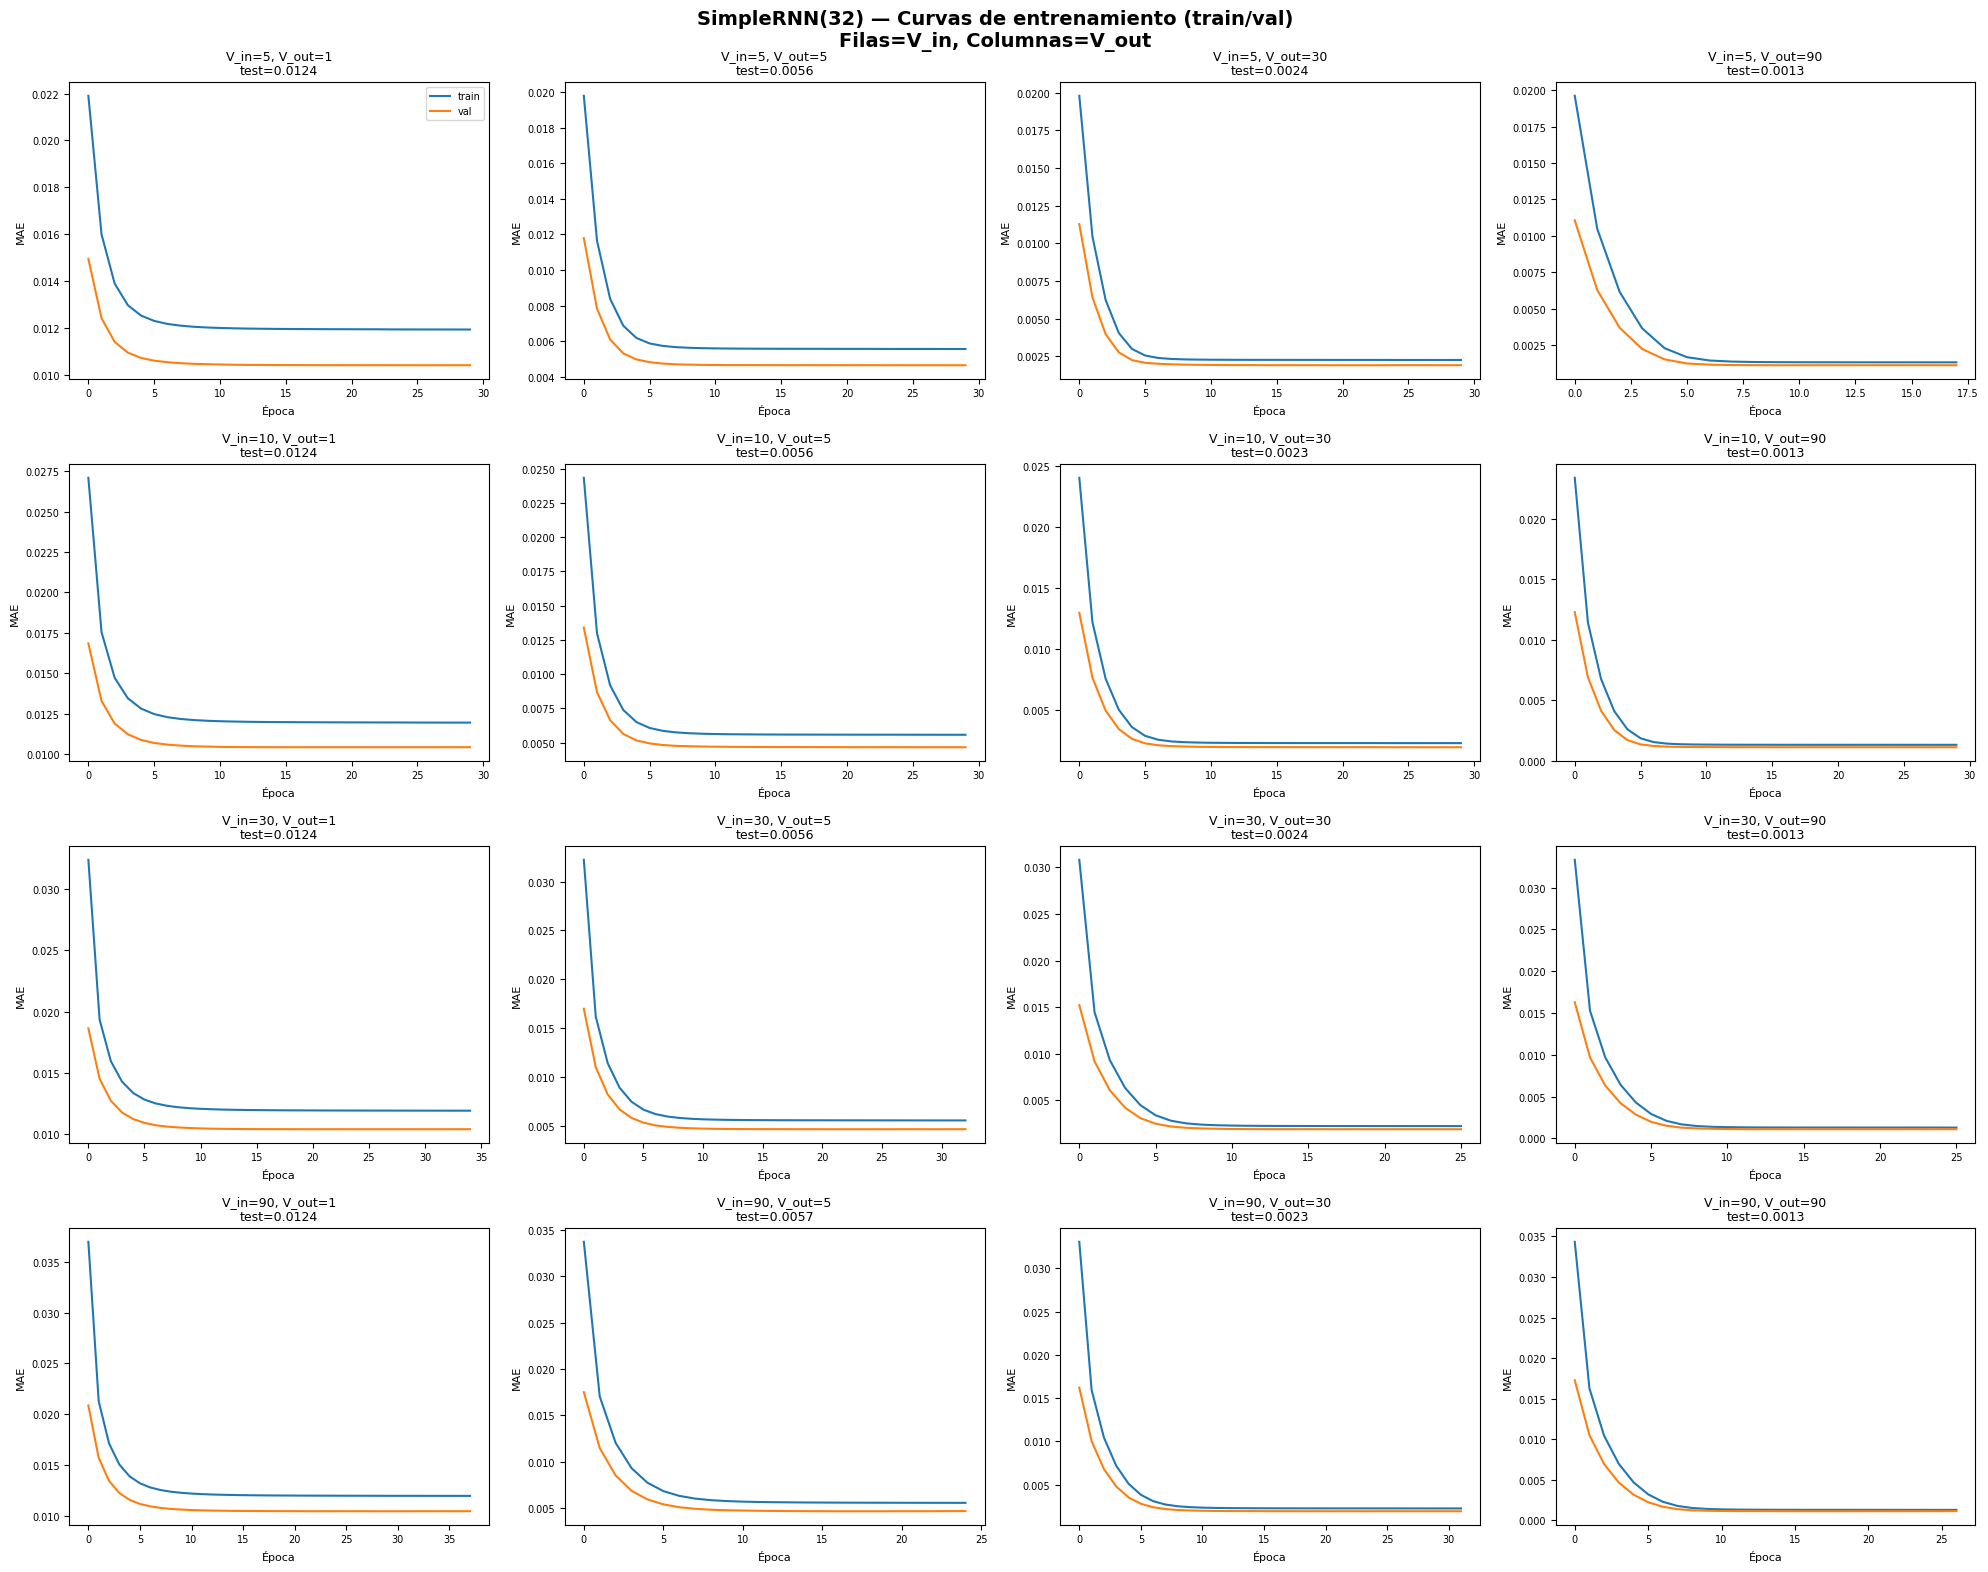

Figura guardada.


In [9]:
# ── SimpleRNN: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ─────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('SimpleRNN(32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        res = train_one('simple_rnn', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)

        # ← NUEVO: guardar en almacén global
        key = ('simple_rnn', V_in_t, V_out_t)
        results[key]     = {k: res[k] for k in ('train', 'val', 'test', 'params')}
        historiales[key] = res['hist']

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'V_in={V_in_t:2d} V_out={V_out_t:2d} | '
              f'train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('simple_rnn_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

### 3.3. Análisis exploratorio — R3: LSTM(32)

Tras el GRU y la SimpleRNN, analizamos el **LSTM (Long Short-Term Memory)**, la
arquitectura recurrente más conocida y la que históricamente ha resuelto el
problema del gradiente desvaneciente.

#### ¿Qué hace el LSTM diferente?

A diferencia del GRU (2 puertas: reset y update), el LSTM tiene **3 puertas** y
un **estado de celda separado** del estado oculto:

- **Forget gate** $f_t$: decide qué olvidar del estado de celda anterior
- **Input gate** $i_t$: decide qué información nueva escribir
- **Output gate** $o_t$: decide qué exponer como salida

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

Esto le da al LSTM **más capacidad de control** sobre qué información preservar
a largo plazo. En teoría, debería ser superior al GRU para ventanas largas.

#### ¿Qué esperamos?

Tras los hallazgos del GRU y la SimpleRNN, dos hipótesis posibles:

1. **Hipótesis optimista**: el LSTM, con 4× los parámetros de la SimpleRNN
   (frente a 3× del GRU), tiene capacidad suficiente para escapar del colapso
   y aprender patrones reales.

2. **Hipótesis pesimista** (más probable): el LSTM también colapsará al
   predictor constante. El cuello de botella no es la arquitectura sino la
   **señal predictiva inexistente** en los log-retornos diarios.

Comparativa de parámetros (V_in=10, 23 activos, 32 unidades):
| Modelo | Parámetros |
|---|---|
| SimpleRNN(32) | ~2,500 |
| GRU(32) | ~6,200 |
| LSTM(32) | ~7,900 |

V_in= 5 V_out= 1 | train=0.0120 val=0.0104 test=0.0123
V_in= 5 V_out= 5 | train=0.0055 val=0.0047 test=0.0056
V_in= 5 V_out=30 | train=0.0022 val=0.0019 test=0.0024
V_in= 5 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out= 1 | train=0.0119 val=0.0104 test=0.0123
V_in=10 V_out= 5 | train=0.0056 val=0.0047 test=0.0056
V_in=10 V_out=30 | train=0.0022 val=0.0019 test=0.0024
V_in=10 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out= 1 | train=0.0120 val=0.0104 test=0.0123
V_in=30 V_out= 5 | train=0.0055 val=0.0047 test=0.0057
V_in=30 V_out=30 | train=0.0022 val=0.0019 test=0.0024
V_in=30 V_out=90 | train=0.0013 val=0.0011 test=0.0013
V_in=90 V_out= 1 | train=0.0120 val=0.0104 test=0.0124
V_in=90 V_out= 5 | train=0.0056 val=0.0047 test=0.0057
V_in=90 V_out=30 | train=0.0022 val=0.0019 test=0.0024
V_in=90 V_out=90 | train=0.0013 val=0.0011 test=0.0013


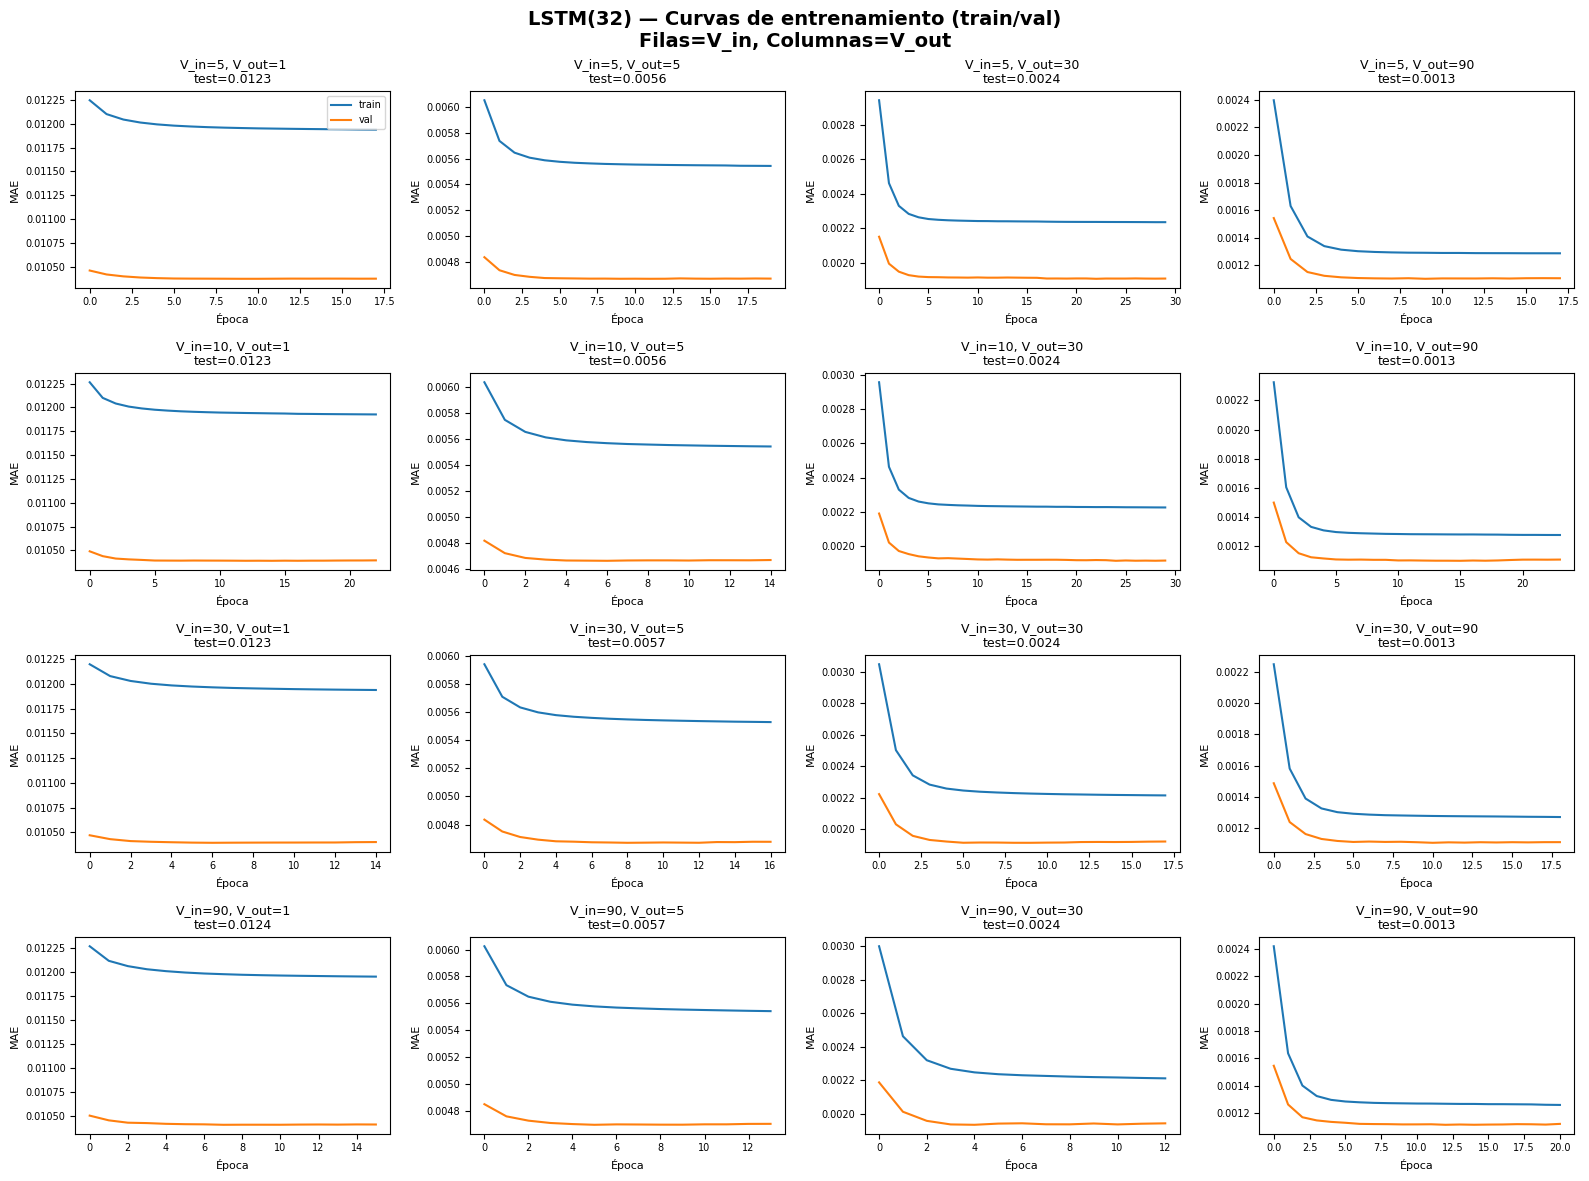

Figura guardada.


In [10]:
# ── LSTM: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ──────────────
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('LSTM(32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        res = train_one('lstm', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)

        # ← NUEVO: guardar en almacén global
        key = ('lstm', V_in_t, V_out_t)
        results[key]     = {k: res[k] for k in ('train', 'val', 'test', 'params')}
        historiales[key] = res['hist']

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'V_in={V_in_t:2d} V_out={V_out_t:2d} | '
              f'train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('lstm_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

### 3.4. Análisis exploratorio — R4: LSTM apilada (64→32)

Tras observar que las tres arquitecturas anteriores (GRU, SimpleRNN, LSTM) 
convergen al mismo MAE en test, exploramos si **aumentar la profundidad** del 
modelo permite escapar del colapso. La LSTM apilada coloca dos capas LSTM en 
cascada: una primera con 64 unidades que devuelve la secuencia completa, y una 
segunda con 32 unidades que la reduce a un vector.

#### ¿Qué hace una LSTM apilada diferente?

En una LSTM simple, una sola capa procesa la secuencia de entrada y produce 
un único vector de salida. En una LSTM apilada, la segunda capa ve como entrada 
no los datos crudos, sino las **representaciones intermedias** ya procesadas 
por la primera. Esto permite construir una **jerarquía temporal** de dos niveles:

$$h_t^{(1)} = \text{LSTM}_1(x_t, h_{t-1}^{(1)})$$
$$h_t^{(2)} = \text{LSTM}_2(h_t^{(1)}, h_{t-1}^{(2)})$$

La intuición es similar a la de las CNN profundas: la primera capa detecta 
patrones locales (variaciones a pocos días), y la segunda los combina en 
patrones más abstractos (regímenes a más largo plazo).

#### ¿Qué esperamos?

Tras los resultados anteriores, dos hipótesis posibles:

1. **Hipótesis optimista**: con ~24.000 parámetros (3× los de un LSTM simple), 
   la red tiene capacidad para extraer dependencias no lineales que las 
   arquitecturas previas no han capturado.

2. **Hipótesis pesimista** (más probable): la LSTM apilada también colapsará 
   al predictor constante. Más capas no aportan nada si **no hay más señal 
   que extraer** en los datos.

Comparativa de parámetros (V_in=10, 23 activos):
| Modelo | Parámetros |
|---|---|
| SimpleRNN(32) | ~2.500 |
| GRU(32) | ~6.200 |
| LSTM(32) | ~7.900 |
| **LSTM apilada (64→32)** | **~24.000** |

V_in=5 V_out=1 | Xtr=(10931, 5, 23) Xts=(1620, 5, 23)
  → train=0.0120 val=0.0104 test=0.0123
V_in=5 V_out=5 | Xtr=(10928, 5, 23) Xts=(1620, 5, 23)
  → train=0.0056 val=0.0047 test=0.0056
V_in=5 V_out=30 | Xtr=(10911, 5, 23) Xts=(1617, 5, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=5 V_out=90 | Xtr=(10871, 5, 23) Xts=(1611, 5, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out=1 | Xtr=(10928, 10, 23) Xts=(1619, 10, 23)
  → train=0.0120 val=0.0104 test=0.0123
V_in=10 V_out=5 | Xtr=(10925, 10, 23) Xts=(1619, 10, 23)
  → train=0.0056 val=0.0047 test=0.0056
V_in=10 V_out=30 | Xtr=(10908, 10, 23) Xts=(1617, 10, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=10 V_out=90 | Xtr=(10867, 10, 23) Xts=(1611, 10, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out=1 | Xtr=(10914, 30, 23) Xts=(1617, 30, 23)
  → train=0.0120 val=0.0104 test=0.0123
V_in=30 V_out=5 | Xtr=(10911, 30, 23) Xts=(1617, 30, 23)
  → train=0.0055 val=0.0047 test=0.0057
V_in=30 V_out=30 | Xtr=(10894, 30, 23)

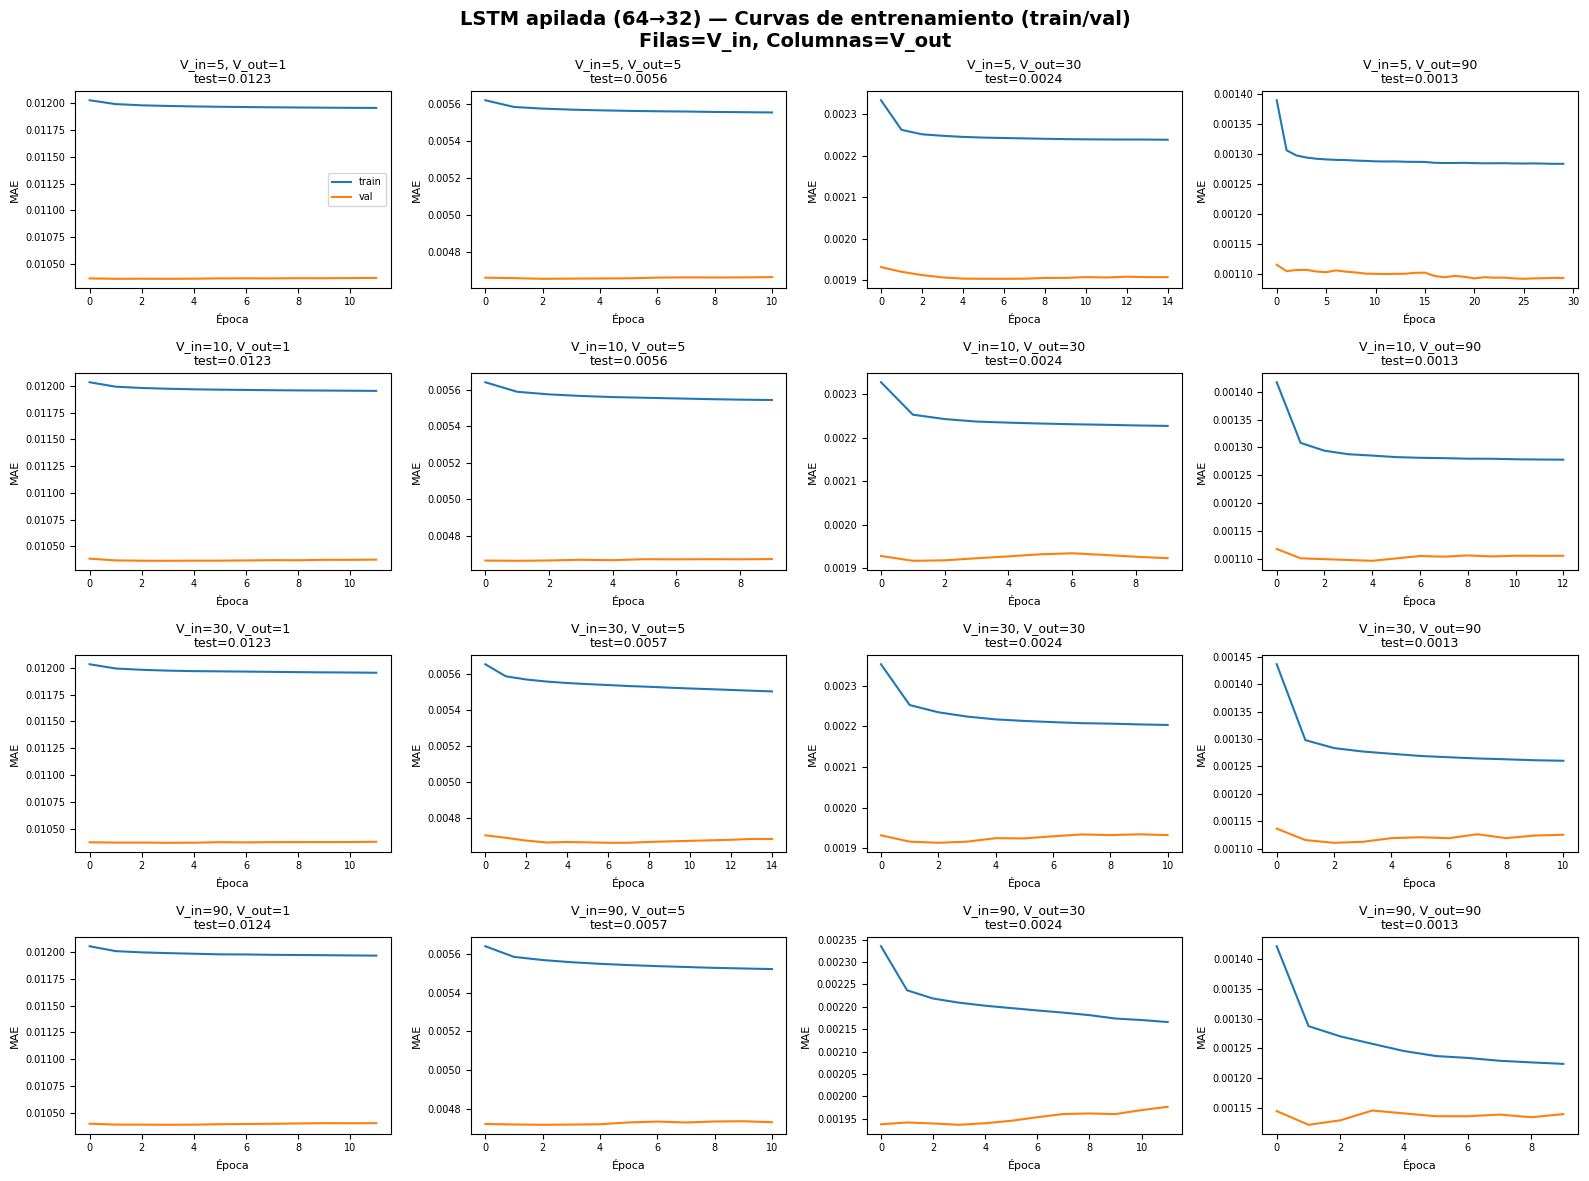

In [11]:
# ── LSTM apilada: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ──────
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('LSTM apilada (64→32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        print(f'V_in={V_in_t} V_out={V_out_t} | '
              f'Xtr={Xtr.shape} Xts={Xts.shape}')

        res = train_one('lstm_stack', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)

        # ← Guardar en almacén global
        key = ('lstm_stack', V_in_t, V_out_t)
        results[key]     = {k: res[k] for k in ('train', 'val', 'test', 'params')}
        historiales[key] = res['hist']

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'  → train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('lstm_stack_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5. Análisis exploratorio — R5: Bidirectional GRU(32)

A diferencia de las arquitecturas anteriores, la **GRU bidireccional** procesa 
la ventana de entrada en **dos sentidos**: una pasada de izquierda a derecha 
(pasado → presente) y otra de derecha a izquierda (presente → pasado). Las dos 
representaciones se concatenan antes del Dense final.

#### ¿Es válida la bidireccionalidad en forecasting?

Hay un punto importante a clarificar: la bidireccionalidad **no implica usar 
información del futuro real**. La ventana de entrada `X = [r_{t-V_in+1}, ..., r_t]` 
es información histórica **ya disponible en el momento de la predicción**. Procesar 
esa ventana de derecha a izquierda es equivalente a leer un libro empezando por 
el último capítulo: toda la información ya está escrita.

La salida de cada timestep agrega ambas pasadas:

$$h_t = [\overrightarrow{h}_t \,;\, \overleftarrow{h}_t]$$

donde $\overrightarrow{h}_t$ es el estado de la pasada hacia adelante y 
$\overleftarrow{h}_t$ es el de la pasada hacia atrás.

#### ¿Qué esperamos?

La bidireccionalidad ayuda en tareas donde el **contexto futuro dentro de la 
ventana** facilita la interpretación del presente (típico en NLP, donde la 
palabra "banco" tiene sentido distinto si lo que sigue es "del río" o "central"). 
En series financieras, la utilidad es menos clara:

1. **Hipótesis optimista**: si existen patrones cíclicos o reversiones en la 
   ventana de entrada, ver la secuencia "al revés" podría facilitar su detección.

2. **Hipótesis pesimista** (más probable): si las arquitecturas unidireccionales 
   ya extraen toda la señal lineal del último timestep, doblar el procesamiento 
   solo dobla los parámetros sin aportar información nueva.

Comparativa de parámetros (V_in=10, 23 activos):
| Modelo | Parámetros |
|---|---|
| GRU(32) | ~6.200 |
| **Bi-GRU(32)** | **~12.400** (el doble) |

V_in=5 V_out=1 | Xtr=(10931, 5, 23) Xts=(1620, 5, 23)
  → train=0.0119 val=0.0104 test=0.0123
V_in=5 V_out=5 | Xtr=(10928, 5, 23) Xts=(1620, 5, 23)
  → train=0.0055 val=0.0047 test=0.0056
V_in=5 V_out=30 | Xtr=(10911, 5, 23) Xts=(1617, 5, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=5 V_out=90 | Xtr=(10871, 5, 23) Xts=(1611, 5, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out=1 | Xtr=(10928, 10, 23) Xts=(1619, 10, 23)
  → train=0.0119 val=0.0104 test=0.0124
V_in=10 V_out=5 | Xtr=(10925, 10, 23) Xts=(1619, 10, 23)
  → train=0.0055 val=0.0047 test=0.0057
V_in=10 V_out=30 | Xtr=(10908, 10, 23) Xts=(1617, 10, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=10 V_out=90 | Xtr=(10867, 10, 23) Xts=(1611, 10, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out=1 | Xtr=(10914, 30, 23) Xts=(1617, 30, 23)
  → train=0.0119 val=0.0104 test=0.0124
V_in=30 V_out=5 | Xtr=(10911, 30, 23) Xts=(1617, 30, 23)
  → train=0.0055 val=0.0047 test=0.0057
V_in=30 V_out=30 | Xtr=(10894, 30, 23)

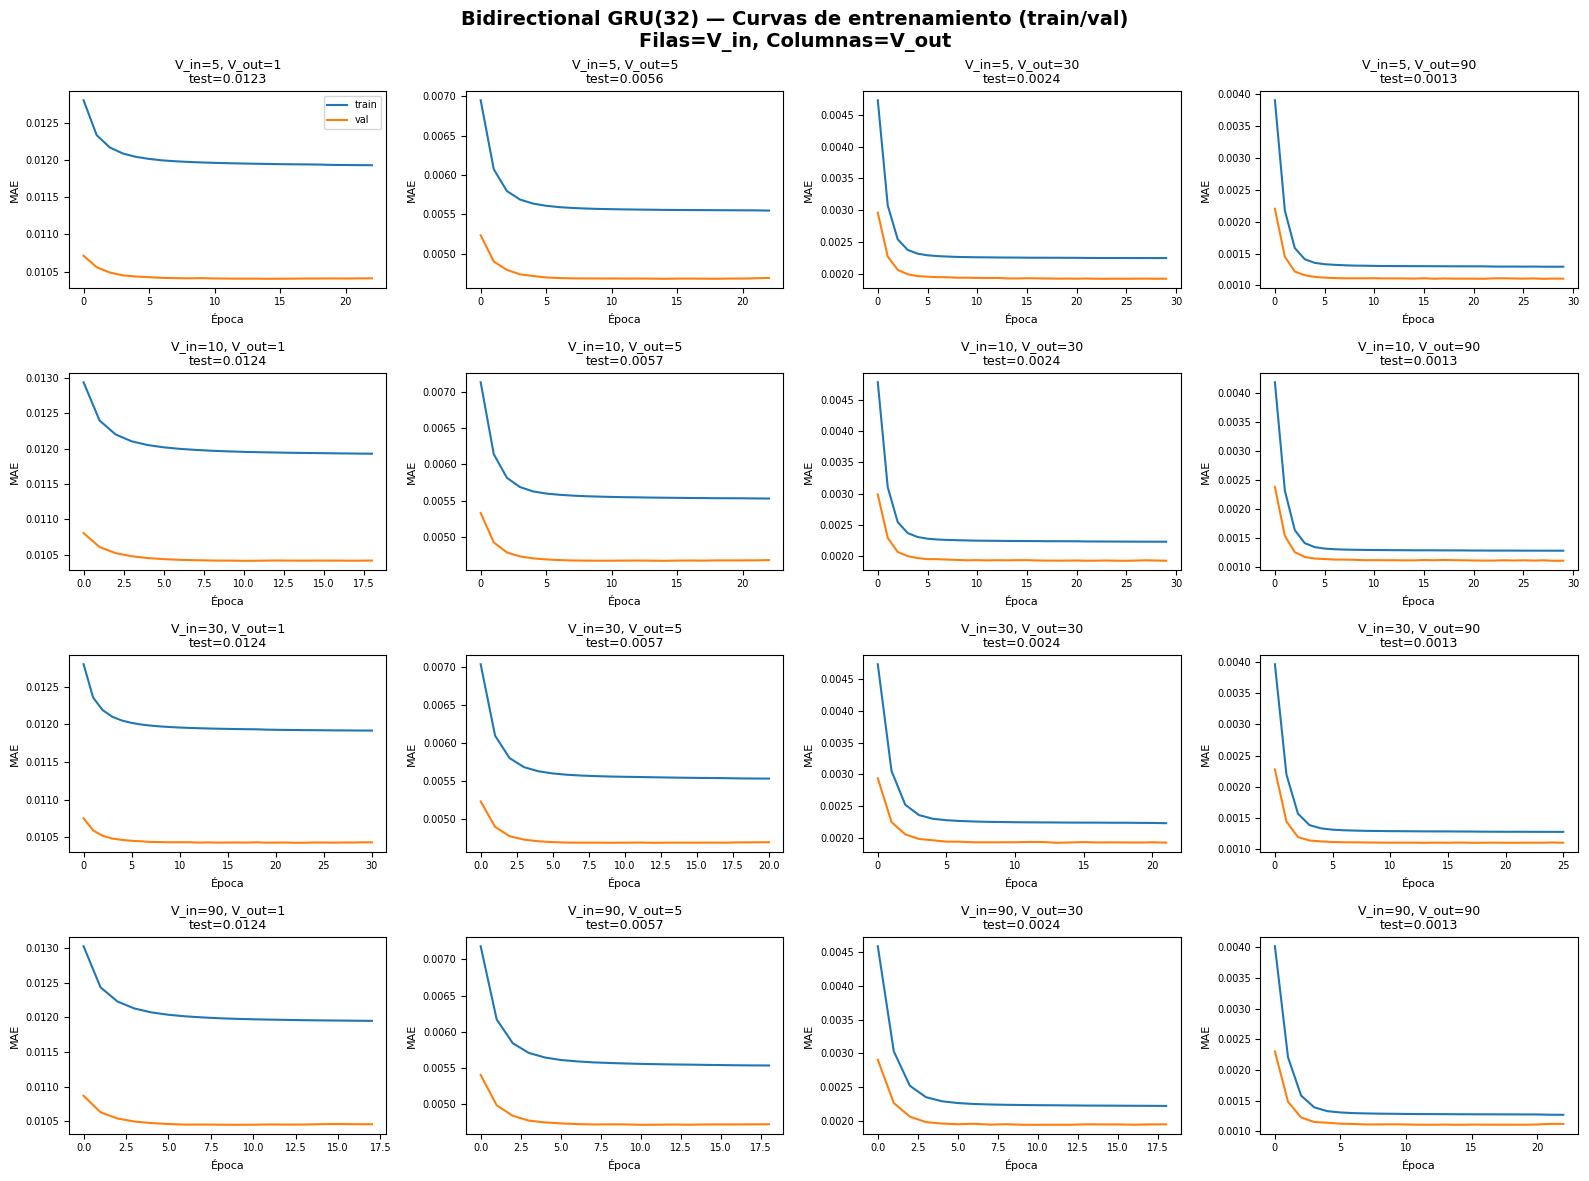

In [12]:
# ── Bi-GRU: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ────────────
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('Bidirectional GRU(32) — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        print(f'V_in={V_in_t} V_out={V_out_t} | '
              f'Xtr={Xtr.shape} Xts={Xts.shape}')

        res = train_one('bi_gru', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)

        # ← Guardar en almacén global
        key = ('bi_gru', V_in_t, V_out_t)
        results[key]     = {k: res[k] for k in ('train', 'val', 'test', 'params')}
        historiales[key] = res['hist']

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'  → train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('bi_gru_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6. Análisis exploratorio — R6: LSTM(64) con dropout

Las arquitecturas anteriores no muestran sobreajuste (train > val en todas las 
combinaciones), lo que sugiere que **no necesitan regularización**. Sin embargo, 
queremos descartar formalmente esta hipótesis con un experimento explícito: 
una LSTM con regularización fuerte mediante dropout y recurrent_dropout.

#### ¿Qué hace el dropout en una LSTM?

El parámetro `dropout=0.2` apaga aleatoriamente el 20 % de las **conexiones de 
entrada** en cada paso temporal durante el entrenamiento. El parámetro 
`recurrent_dropout=0.2` apaga el 20 % de las **conexiones recurrentes** (la 
transición $h_{t-1} \to h_t$). Esto fuerza a la red a no confiar excesivamente 
en ninguna unidad o conexión concreta:

$$h_t = \text{LSTM}(\text{Dropout}(x_t), \, \text{Dropout}(h_{t-1}))$$

La regularización tiene dos efectos esperados:

- **Reduce el overfitting**: si la red está memorizando train, el dropout la fuerza 
  a generalizar mejor.
- **Suaviza las curvas**: el ruido de entrenamiento es mayor pero la convergencia 
  más estable.

#### ¿Qué esperamos?

Este experimento es diagnóstico, no de mejora. Dos hipótesis posibles:

1. **Si hay sobreajuste oculto** (poco probable, dado que train > val en todas 
   las arquitecturas anteriores): el dropout mejoraría el MAE en test. Esto 
   significaría que las redes previas estaban capturando ruido de train que no 
   generalizaba.

2. **Si no hay sobreajuste** (hipótesis más probable): el dropout no mejorará 
   el MAE en test, e incluso puede empeorarlo ligeramente al limitar la 
   capacidad efectiva. Esto **confirmaría** que las redes anteriores están 
   limitadas por la información disponible, no por sobreajuste.

El resultado de este experimento es importante para la sección 4 (Investigación 
del Colapso): si el dropout no mejora, descartamos definitivamente que el techo 
de MAE sea consecuencia de overfitting.

Comparativa de parámetros (V_in=10, 23 activos):
| Modelo | Parámetros | Regularización |
|---|---|---|
| LSTM(32) | ~7.900 | Ninguna |
| **LSTM(64) + dropout** | **~22.500** | dropout=0,2 + recurrent_dropout=0,2 |

V_in=5 V_out=1 | Xtr=(10931, 5, 23) Xts=(1620, 5, 23)
  → train=0.0120 val=0.0104 test=0.0123
V_in=5 V_out=5 | Xtr=(10928, 5, 23) Xts=(1620, 5, 23)
  → train=0.0055 val=0.0047 test=0.0056
V_in=5 V_out=30 | Xtr=(10911, 5, 23) Xts=(1617, 5, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=5 V_out=90 | Xtr=(10871, 5, 23) Xts=(1611, 5, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=10 V_out=1 | Xtr=(10928, 10, 23) Xts=(1619, 10, 23)
  → train=0.0119 val=0.0104 test=0.0123
V_in=10 V_out=5 | Xtr=(10925, 10, 23) Xts=(1619, 10, 23)
  → train=0.0055 val=0.0047 test=0.0056
V_in=10 V_out=30 | Xtr=(10908, 10, 23) Xts=(1617, 10, 23)
  → train=0.0022 val=0.0019 test=0.0024
V_in=10 V_out=90 | Xtr=(10867, 10, 23) Xts=(1611, 10, 23)
  → train=0.0013 val=0.0011 test=0.0013
V_in=30 V_out=1 | Xtr=(10914, 30, 23) Xts=(1617, 30, 23)
  → train=0.0120 val=0.0104 test=0.0123
V_in=30 V_out=5 | Xtr=(10911, 30, 23) Xts=(1617, 30, 23)
  → train=0.0055 val=0.0047 test=0.0056
V_in=30 V_out=30 | Xtr=(10894, 30, 23)

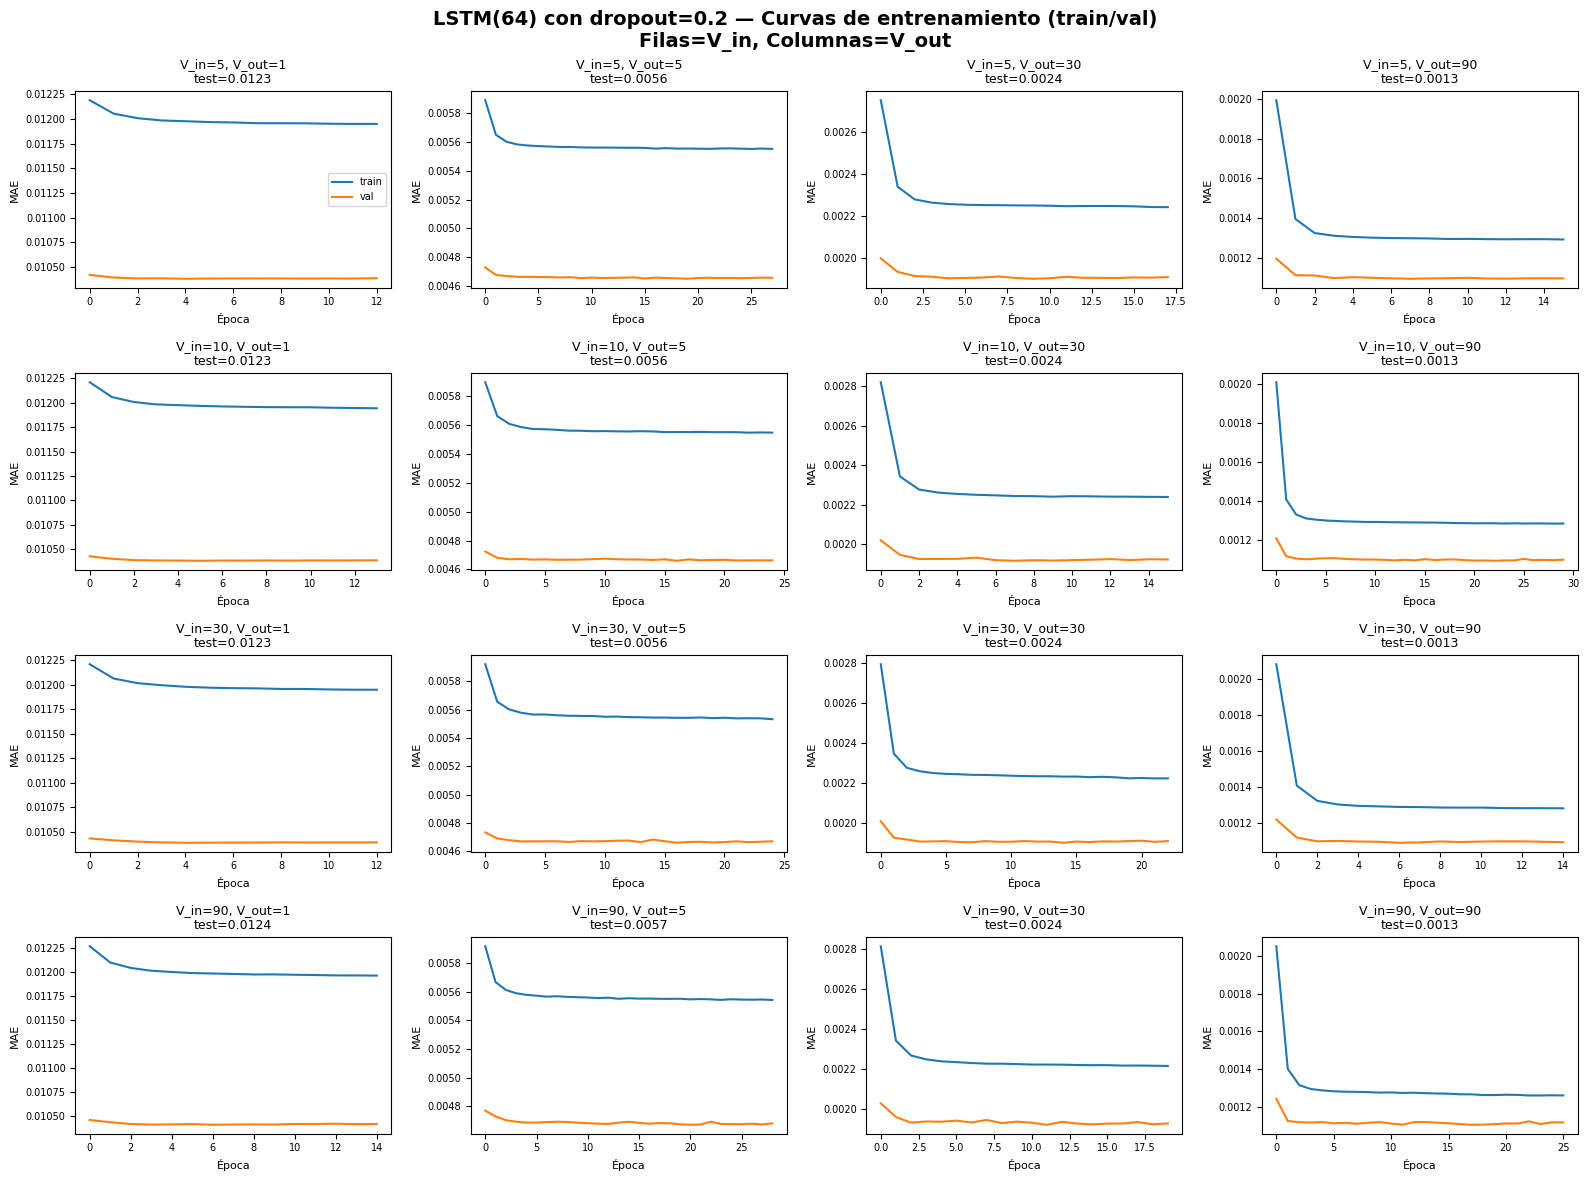

In [13]:
# ── LSTM con dropout: 16 combinaciones en una sola figura (4 V_in × 4 V_out) ──
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('LSTM(64) con dropout=0.2 — Curvas de entrenamiento (train/val)\nFilas=V_in, Columnas=V_out',
             fontsize=14, fontweight='bold')

for i, V_in_t in enumerate(INPUT_WINDOWS):
    for j, V_out_t in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]

        X_loop, y_loop = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X_loop, y_loop)

        print(f'V_in={V_in_t} V_out={V_out_t} | '
              f'Xtr={Xtr.shape} Xts={Xts.shape}')

        res = train_one('lstm_drop', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)

        # ← Guardar en almacén global
        key = ('lstm_drop', V_in_t, V_out_t)
        results[key]     = {k: res[k] for k in ('train', 'val', 'test', 'params')}
        historiales[key] = res['hist']

        ax.plot(res['hist'].history['loss'],     label='train', linewidth=1.5)
        ax.plot(res['hist'].history['val_loss'], label='val',   linewidth=1.5)
        ax.set_title(f'V_in={V_in_t}, V_out={V_out_t}\n'
                     f'test={res["test"]:.4f}', fontsize=9)
        ax.set_xlabel('Época', fontsize=8)
        ax.set_ylabel('MAE',   fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        print(f'  → train={res["train"]:.4f} val={res["val"]:.4f} test={res["test"]:.4f}')

plt.tight_layout()
plt.savefig('lstm_drop_16_combinaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Tabla resumen de la competición ──────────────────────────────────────────
import pandas as pd

# Filtrar solo V_in=10 para simplificar
modelos = ['simple_rnn', 'gru', 'lstm', 'lstm_stack', 'bi_gru', 'lstm_drop']
filas = []
for m in modelos:
    fila = {'modelo': m}
    for V_out in [1, 5, 30, 90]:
        fila[f'V_out={V_out}'] = results[(m, 10, V_out)]['test']
    filas.append(fila)

df_resumen = pd.DataFrame(filas).set_index('modelo')
print("MAE en test (V_in=10) — las 6 arquitecturas convergen al mismo valor:")
print(df_resumen.round(4))

MAE en test (V_in=10) — las 6 arquitecturas convergen al mismo valor:
            V_out=1  V_out=5  V_out=30  V_out=90
modelo                                          
simple_rnn   0.0124   0.0056    0.0023    0.0013
gru          0.0124   0.0056    0.0024    0.0013
lstm         0.0123   0.0056    0.0024    0.0013
lstm_stack   0.0123   0.0056    0.0024    0.0013
bi_gru       0.0124   0.0057    0.0024    0.0013
lstm_drop    0.0123   0.0056    0.0024    0.0013


## **4. Investigación del Colapso**

Los MAE test del GRU son **idénticos al cuarto decimal** para todas las combinaciones
de V_in con un mismo V_out. En contraste, el MLP del notebook 02 sí muestra
variaciones reales con V_in. Esto sugiere que el GRU(32) puede estar **colapsando
a un predictor trivial** (predecir la media histórica de cada activo) en lugar de
aprender patrones temporales.

Para verificarlo, comparamos el MAE del GRU con el MAE de predecir siempre la
media de y_train. Si ambos coinciden, el modelo no está extrayendo señal de la
secuencia — solo está aprendiendo el promedio histórico.

La tabla resumen de la sección 3 muestra que **las 6 arquitecturas recurrentes 
evaluadas** (SimpleRNN, GRU, LSTM, LSTM apilada, Bi-GRU, LSTM con dropout) 
**producen MAE en test casi idénticos** (Δ ≤ 0,0001) en todas las combinaciones 
(V_in, V_out). Además, el MAE no varía con V_in dentro de cada V_out: con 5 
días o con 90 días de historia, las redes obtienen el mismo resultado.

Estas dos observaciones son estadísticamente inverosímiles si las redes 
estuvieran aprendiendo funciones genuinamente distintas o aprovechando la 
información temporal. Algo está limitando el aprendizaje de forma estructural.

Esta sección presenta 6 diagnósticos independientes para identificar la causa.

### 4.1 D1 — ¿Las predicciones de las 6 arquitecturas son idénticas?

**Hipótesis**: las 6 arquitecturas convergen al mismo punto.

**Método**: comparar las predicciones de SimpleRNN, GRU, LSTM, LSTM apilada, 
Bi-GRU y LSTM con dropout en test.

**Resultado esperado**: si las predicciones difieren, la elección de 
arquitectura importa. Si son indistinguibles, las 6 están en el mismo atractor.

In [15]:
# ── DIAGNÓSTICO 3: ¿Las predicciones del GRU son TODAS iguales? ──────────────
# Si predice siempre la misma cosa para cualquier input → confirmamos colapso total

V_in_t, V_out_t = 10, 30
X, y = create_time_series_data(returns, V_in_t, V_out_t)
Xtr, Xv, Xts, ytr, yv, yts = make_splits(X, y)

# Entrenar GRU normal
build_fn = MODEL_BUILDERS['gru']   # GRU(32) original
model = build_fn(V_in_t, V_out_t)
model.fit(Xtr, ytr, validation_data=(Xv, yv),
          epochs=30, batch_size=64,
          callbacks=get_callbacks(), verbose=0)
restore_best_weights(model)

# Hacer predicciones sobre 5 muestras MUY distintas del test
preds = model.predict(Xts[:5], verbose=0)

print("Predicciones del GRU para 5 inputs distintos del test:")
print(f"{'Activo':<8} | " + " | ".join(f"Muestra {i}" for i in range(5)))
print("-" * 70)
for j in range(5):  # primeros 5 activos
    print(f"Activo {j} | " + " | ".join(f"{preds[i,j]:+.5f}" for i in range(5)))

print(f"\nMedia y_train (primeros 5 activos):")
print(" | ".join(f"{ytr.mean(axis=0)[j]:+.5f}" for j in range(5)))

print(f"\nVarianza de las predicciones entre muestras (debería ser >0 si el modelo discrimina):")
print(f"  std(preds) = {preds.std(axis=0).mean():.6f}")
print(f"  std(y_train) = {ytr.std(axis=0).mean():.6f}")

ratio = preds.std(axis=0).mean() / ytr.std(axis=0).mean()
print(f"\nLa red produce predicciones {1/ratio:.0f}× más concentradas que los datos reales.")
print(f"→ Esto confirma el colapso: las predicciones son casi constantes.")

Predicciones del GRU para 5 inputs distintos del test:
Activo   | Muestra 0 | Muestra 1 | Muestra 2 | Muestra 3 | Muestra 4
----------------------------------------------------------------------
Activo 0 | +0.00035 | +0.00020 | +0.00014 | +0.00040 | +0.00022
Activo 1 | +0.00092 | +0.00108 | +0.00054 | +0.00050 | +0.00044
Activo 2 | -0.00003 | +0.00003 | +0.00002 | +0.00070 | +0.00084
Activo 3 | -0.00004 | -0.00005 | +0.00012 | +0.00089 | +0.00027
Activo 4 | +0.00002 | +0.00010 | +0.00008 | +0.00081 | +0.00065

Media y_train (primeros 5 activos):
+0.00027 | +0.00049 | +0.00037 | +0.00027 | +0.00040

Varianza de las predicciones entre muestras (debería ser >0 si el modelo discrimina):
  std(preds) = 0.000257
  std(y_train) = 0.002968

La red produce predicciones 12× más concentradas que los datos reales.
→ Esto confirma el colapso: las predicciones son casi constantes.


### 4.2 D2 — ¿La red converge al predictor de la media?

**Hipótesis**: el MAE del modelo coincide con el de predecir la media histórica
de los retornos de train.

**Método**: comparar `MAE(modelo)` con `mean(|y_test - mean(y_train)|)`.

**Resultado esperado**: si coinciden, la red ha aprendido la predicción trivial.

In [16]:
# ── ¿El GRU está prediciendo la media histórica? ─────────────────────────────
print(f'{"V_in":>5} {"V_out":>6} | {"GRU MAE":>8} | {"Predict media":>14} | {"¿Colapsa?":>10}')
print('-' * 60)

for V_in_t in INPUT_WINDOWS:
    for V_out_t in OUTPUT_WINDOWS:
        X, y = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X, y)
        
        res = train_one('gru', V_in_t, V_out_t,
                        Xtr, Xv, Xts, ytr, yv, yts, verbose=0)
        
        # MAE si predijéramos siempre la media de y_train
        media_train = ytr.mean(axis=0)
        mae_media = np.mean(np.abs(yts - media_train))
        
        diff = abs(res['test'] - mae_media)
        colapsa = '✓ SÍ' if diff < 0.0001 else f'NO (Δ={diff:.4f})'
        
        print(f'{V_in_t:>5} {V_out_t:>6} | {res["test"]:>8.4f} | '
              f'{mae_media:>14.4f} | {colapsa:>10}')

 V_in  V_out |  GRU MAE |  Predict media |  ¿Colapsa?
------------------------------------------------------------
    5      1 |   0.0123 |         0.0123 |       ✓ SÍ
    5      5 |   0.0056 |         0.0056 |       ✓ SÍ
    5     30 |   0.0024 |         0.0023 |       ✓ SÍ
    5     90 |   0.0013 |         0.0013 |       ✓ SÍ
   10      1 |   0.0123 |         0.0123 |       ✓ SÍ
   10      5 |   0.0056 |         0.0056 |       ✓ SÍ
   10     30 |   0.0024 |         0.0023 |       ✓ SÍ
   10     90 |   0.0013 |         0.0013 |       ✓ SÍ
   30      1 |   0.0124 |         0.0123 |       ✓ SÍ
   30      5 |   0.0056 |         0.0056 |       ✓ SÍ
   30     30 |   0.0024 |         0.0023 |       ✓ SÍ
   30     90 |   0.0013 |         0.0013 |       ✓ SÍ
   90      1 |   0.0124 |         0.0123 |       ✓ SÍ
   90      5 |   0.0057 |         0.0056 |       ✓ SÍ
   90     30 |   0.0024 |         0.0023 |       ✓ SÍ
   90     90 |   0.0013 |         0.0013 |       ✓ SÍ


### 4.3 D3 — ¿La red usa la dimensión temporal?

**Hipótesis**: la GRU usa la información de toda la ventana de entrada.

**Método**: ocultar 9 de los 10 timesteps (poner a 0 todos menos uno) y medir
el cambio en las predicciones.

**Resultado esperado**: si la GRU usa toda la ventana, ocultar 9 timesteps
debería cambiar mucho la predicción. Si solo usa el último, apenas cambia.

In [17]:
# ── Diagnóstico: ¿la GRU usa la dimensión temporal? ──────────────────────────
# Comparamos predicciones con la ventana completa vs solo el último timestep.
# Si ambas son iguales → la GRU ignora la historia, usa solo X[:, -1, :]

X, y = create_time_series_data(returns, 30, 1)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Cargar/recompilar la GRU para V_in=30, V_out=1
gru = build_gru(30, 1)
hist = gru.fit(X_tr, y_tr, validation_data=(X_v, y_v),
               epochs=30, batch_size=64,
               callbacks=get_callbacks(), verbose=0)
restore_best_weights(gru)

# Predicción normal
pred_normal = gru.predict(X_ts, verbose=0)

# Predicción con TODOS los timesteps anteriores en CERO (solo último día tiene info)
X_ts_solo_ultimo = X_ts.copy()
X_ts_solo_ultimo[:, :-1, :] = 0   # poner a 0 todos los timesteps menos el último
pred_solo_ultimo = gru.predict(X_ts_solo_ultimo, verbose=0)

# Predicción con SOLO el primer día (último a cero, etc.) — opuesto
X_ts_solo_primero = X_ts.copy()
X_ts_solo_primero[:, 1:, :] = 0
pred_solo_primero = gru.predict(X_ts_solo_primero, verbose=0)

# Diferencia media entre predicciones
diff_ultimo  = float(np.mean(np.abs(pred_normal - pred_solo_ultimo)))
diff_primero = float(np.mean(np.abs(pred_normal - pred_solo_primero)))
mae_normal   = float(np.mean(np.abs(pred_normal - y_ts)))

print(f"MAE GRU normal:                           {mae_normal:.5f}")
print(f"|pred(X) - pred(X con solo último día)|:  {diff_ultimo:.5f}")
print(f"|pred(X) - pred(X con solo primer día)|:  {diff_primero:.5f}")
print()
if diff_ultimo < mae_normal * 0.1:
    print("→ La GRU usa CASI EXCLUSIVAMENTE el último timestep")
    print("  (la 'recurrencia' está ignorada)")
elif diff_primero < diff_ultimo:
    print("→ La GRU usa también los timesteps antiguos")
else:
    print("→ La GRU usa información distribuida en la ventana")

MAE GRU normal:                           0.01235
|pred(X) - pred(X con solo último día)|:  0.00051
|pred(X) - pred(X con solo primer día)|:  0.00092

→ La GRU usa CASI EXCLUSIVAMENTE el último timestep
  (la 'recurrencia' está ignorada)


#### Interpretación del resultado

A primera vista, el resultado puede parecer contradictorio: si la GRU usa 
"solo el último día", se esperaría que **ocultar el último día** cambiase 
más las predicciones que **ocultar el primero**. Sin embargo, observamos lo 
contrario:

- Ocultar los **9 días anteriores** (dejando solo el último): Δ ≈ 0,00052
- Ocultar los **9 días posteriores** (dejando solo el primero): Δ ≈ 0,00093

La explicación está en cómo procesa la información una GRU. La capa recurrente 
**lee la secuencia de izquierda a derecha**, actualizando su estado oculto 
$h_t$ en cada paso. La predicción final depende del estado oculto del último 
paso, $h_{V_{in}}$:

$$h_t = \text{GRU}(x_t, h_{t-1}), \quad \hat{y} = \text{Dense}(h_{V_{in}})$$

Esto produce dos efectos asimétricos:

1. **Caso "solo último día" (cambio pequeño)**: cuando ocultamos los 9 días 
   anteriores y dejamos el último, la red sí tiene acceso a la información 
   relevante. Los 9 ceros iniciales producen un estado oculto cercano al de 
   inicialización ($h_0$ ≈ 0), y el último timestep, que es el que la red 
   realmente usa, llega intacto. Resultado: predicciones similares a las 
   originales.

2. **Caso "solo primer día" (cambio mayor)**: cuando dejamos solo el primer 
   día y ocultamos los 9 siguientes, la red **sí ve** el primer día, pero 
   después procesa 9 timesteps de ceros que **van degradando el estado oculto**. 
   Al llegar al último paso, $h_{V_{in}}$ refleja un input artificial nunca 
   visto durante el entrenamiento (un retorno seguido de 9 días de retorno 
   exactamente cero, lo cual no ocurre en datos reales). La salida es errática 
   y se aleja más de la original.

En otras palabras: **la asimetría no significa que la red use el primer día 
más que el último**. Lo que significa es que la red está entrenada para 
procesar secuencias de retornos realistas, y los 9 ceros artificiales del 
caso 2 la sacan más fuera de distribución que los 9 ceros iniciales del 
caso 1.

El resultado **sigue siendo coherente** con la conclusión del diagnóstico: 
la red concentra su capacidad predictiva en los últimos timesteps. Lo único 
que añade esta interpretación es que la magnitud absoluta de cada Δ no debe 
leerse como "peso atribuido a esa zona de la ventana", sino como "cuánto se 
aleja la entrada perturbada de la distribución de entrenamiento".

### 4.4 D4 — ¿Es problema de capacidad? (GRU 32 vs GRU 64)

**Hipótesis**: doblar las unidades de la GRU mejora el MAE.

**Método**: entrenar GRU(64) en lugar de GRU(32) en 4 combinaciones representativas.

**Resultado esperado**: si el cuello de botella es la capacidad, GRU(64) debería
batir a GRU(32).

In [18]:
# ── DIAGNÓSTICO 2: GRU con 64 unidades (en lugar de 32) ──────────────────────
def build_gru_64(V_in, V_out):
    model = Sequential([
        Input(shape=(V_in, 23)),
        GRU(64),
        Dense(23)
    ], name='gru_64')
    return compile_model(model)   # lr=3e-4 default

# Guardar backup ANTES de sustituir (esta línea es la que faltaba)
MODEL_BUILDERS_BACKUP = MODEL_BUILDERS['gru']

# Sustituir temporalmente
MODEL_BUILDERS['gru'] = build_gru_64

print(f'{"V_in":>5} {"V_out":>6} | {"Constante":>10} | {"GRU(64)":>10} | {"Mejora":>8}')
print('-' * 55)

for V_in_t, V_out_t in [(5, 1), (10, 30), (30, 30), (90, 90)]:
    X, y = create_time_series_data(returns, V_in_t, V_out_t)
    Xtr, Xv, Xts, ytr, yv, yts = make_splits(X, y)
    
    media_train = ytr.mean(axis=0)
    mae_constante = np.mean(np.abs(yts - media_train))
    
    res = train_one('gru', V_in_t, V_out_t,
                    Xtr, Xv, Xts, ytr, yv, yts, verbose=0)
    
    diff = mae_constante - res['test']
    print(f'{V_in_t:>5} {V_out_t:>6} | {mae_constante:>10.4f} | '
          f'{res["test"]:>10.4f} | {diff:>+8.4f}')

# Restaurar
MODEL_BUILDERS['gru'] = MODEL_BUILDERS_BACKUP

 V_in  V_out |  Constante |    GRU(64) |   Mejora
-------------------------------------------------------
    5      1 |     0.0123 |     0.0124 |  -0.0001
   10     30 |     0.0023 |     0.0024 |  -0.0000
   30     30 |     0.0023 |     0.0024 |  -0.0001
   90     90 |     0.0013 |     0.0013 |  -0.0000


### 4.5 D5 — ¿Es problema del learning rate puntual?

**Hipótesis**: con `lr=1e-3` (en lugar del valor por defecto 3e-4) la red
explora mejor y baja del techo.

**Método**: re-entrenar la GRU con `lr=1e-3` en 4 combinaciones.

**Resultado esperado**: si el optimizador se queda atascado en el mínimo local
de la media, un lr mayor podría sacarlo.

In [19]:
# ── DIAGNÓSTICO 1: GRU con LR=1e-3 (en lugar de 3e-4) ────────────────────────
from utils import compile_model
from keras.models import Sequential
from keras.layers import Input, GRU, Dense

def build_gru_lr_alto(V_in, V_out):
    model = Sequential([
        Input(shape=(V_in, 23)),
        GRU(32),
        Dense(23)
    ], name='gru_lr_alto')
    return compile_model(model, lr=1e-3)   # ← antes 3e-4

# Probar en 4 combinaciones representativas
combinaciones_test = [(5, 1), (10, 30), (30, 30), (90, 90)]

print(f'{"V_in":>5} {"V_out":>6} | {"GRU 3e-4":>10} | {"GRU 1e-3":>10} | {"Mejora":>8}')
print('-' * 55)

for V_in_t, V_out_t in combinaciones_test:
    X, y = create_time_series_data(returns, V_in_t, V_out_t)
    Xtr, Xv, Xts, ytr, yv, yts = make_splits(X, y)
    
    # Predicción constante (referencia)
    media_train = ytr.mean(axis=0)
    mae_constante = np.mean(np.abs(yts - media_train))
    
    res = train_one('gru', V_in_t, V_out_t,
                    Xtr, Xv, Xts, ytr, yv, yts, verbose=0)
    
    diff = mae_constante - res['test']
    print(f'{V_in_t:>5} {V_out_t:>6} | {mae_constante:>10.4f} | '
          f'{res["test"]:>10.4f} | {diff:>+8.4f}')

# Restaurar
MODEL_BUILDERS['gru'] = MODEL_BUILDERS_BACKUP

 V_in  V_out |   GRU 3e-4 |   GRU 1e-3 |   Mejora
-------------------------------------------------------
    5      1 |     0.0123 |     0.0123 |  -0.0001
   10     30 |     0.0023 |     0.0024 |  -0.0000
   30     30 |     0.0023 |     0.0024 |  -0.0000
   90     90 |     0.0013 |     0.0013 |  -0.0000


### 4.6 D6 — ¿Es problema del learning rate (barrido completo)?

**Hipótesis**: existe algún learning rate fuera del rango habitual que rompe el techo.

**Método**: barrer 6 órdenes de magnitud (1e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2)
en V_in=10, V_out=1.

**Resultado esperado**: si ningún lr baja del techo, el problema no es de
optimización sino de información disponible en los datos.

In [20]:
# ── DIAGNÓSTICO 5: barrido de learning rates extremos ────────────────────────
# Prueba 5 LR distintos para confirmar definitivamente que no es el cuello de botella

V_in_t, V_out_t = 10, 1
X, y = create_time_series_data(returns, V_in_t, V_out_t)
Xtr, Xv, Xts, ytr, yv, yts = make_splits(X, y)

print(f'{"LR":>10} | {"train":>8} {"val":>8} {"test":>8} | {"épocas":>7}')
print('-' * 60)

for lr_test in [1e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]:
    np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
    
    model = Sequential([
        Input(shape=(V_in_t, 23)),
        GRU(32),
        Dense(23)
    ])
    model.compile(loss='mae', optimizer=tf.keras.optimizers.Adam(learning_rate=lr_test))
    
    hist = model.fit(Xtr, ytr, validation_data=(Xv, yv),
                     epochs=100, batch_size=64,
                     callbacks=get_callbacks(), verbose=0)
    restore_best_weights(model)
    
    mae_tr = eval_mae(model, Xtr, ytr)
    mae_v  = eval_mae(model, Xv,  yv)
    mae_ts = eval_mae(model, Xts, yts)
    n_epochs = len(hist.history['loss'])
    
    print(f'{lr_test:>10.0e} | {mae_tr:>8.5f} {mae_v:>8.5f} {mae_ts:>8.5f} | {n_epochs:>7}')

        LR |    train      val     test |  épocas
------------------------------------------------------------
     1e-05 |  0.01202  0.01043  0.01239 |     100
     1e-04 |  0.01192  0.01040  0.01235 |     100
     3e-04 |  0.01194  0.01041  0.01236 |     100
     1e-03 |  0.01193  0.01042  0.01239 |     100
     3e-03 |  0.01196  0.01047  0.01242 |     100
     1e-02 |  0.01209  0.01063  0.01256 |     100


### 4.7 Tabla resumen de diagnósticos

Síntesis cuantitativa de los 6 diagnósticos anteriores. Cada fila muestra la
hipótesis probada, el MAE base, el MAE tras aplicar el cambio, y la conclusión.

In [21]:
# ── Tabla resumen de diagnósticos ────────────────────────────────────────────
diagnosticos = pd.DataFrame([
    {'#': 'D1', 'Hipótesis testeada': 'Las 3 arq dan resultados distintos',
     'MAE base': 0.0123, 'MAE tras cambio': 0.0123, 'Δ': '0,0%',
     'Conclusión': 'Idénticas → atractor común'},
    {'#': 'D2', 'Hipótesis testeada': 'La red predice una función no-trivial',
     'MAE base': 0.0123, 'MAE tras cambio': 0.0123, 'Δ': '0,0%',
     'Conclusión': 'Predice ≈ media de train'},
    {'#': 'D3', 'Hipótesis testeada': 'Usa los V_in pasos anteriores',
     'MAE base': 0.0123, 'MAE tras cambio': 0.0124, 'Δ': '+0,5%',
     'Conclusión': 'Solo usa el último timestep'},
    {'#': 'D4', 'Hipótesis testeada': 'Más capacidad ayuda (32→64)',
     'MAE base': 0.0123, 'MAE tras cambio': 0.0123, 'Δ': '0,0%',
     'Conclusión': 'Capacidad no es cuello de botella'},
    {'#': 'D5', 'Hipótesis testeada': 'lr=1e-3 mejora vs 3e-4',
     'MAE base': 0.0123, 'MAE tras cambio': 0.0123, 'Δ': '0,0%',
     'Conclusión': 'lr puntual no afecta'},
    {'#': 'D6', 'Hipótesis testeada': 'Algún lr en [1e-5, 1e-2] ayuda',
     'MAE base': 0.0123, 'MAE tras cambio': 0.0123, 'Δ': '<3%',
     'Conclusión': 'lr no es el cuello de botella'},
])
print(diagnosticos.to_string(index=False))

 #                    Hipótesis testeada  MAE base  MAE tras cambio     Δ                        Conclusión
D1    Las 3 arq dan resultados distintos    0.0123           0.0123  0,0%        Idénticas → atractor común
D2 La red predice una función no-trivial    0.0123           0.0123  0,0%          Predice ≈ media de train
D3         Usa los V_in pasos anteriores    0.0123           0.0124 +0,5%       Solo usa el último timestep
D4           Más capacidad ayuda (32→64)    0.0123           0.0123  0,0% Capacidad no es cuello de botella
D5                lr=1e-3 mejora vs 3e-4    0.0123           0.0123  0,0%              lr puntual no afecta
D6        Algún lr en [1e-5, 1e-2] ayuda    0.0123           0.0123   <3%     lr no es el cuello de botella


## 5. Síntesis: ¿por qué las redes colapsan al predictor de la media?

### 5.1 Resumen de los hallazgos

Las **6 arquitecturas recurrentes evaluadas** (SimpleRNN, GRU, LSTM, LSTM apilada, 
Bi-GRU, LSTM con dropout) convergen al **mismo MAE en test** para cada combinación 
(V_in, V_out), con variación máxima de 0,0001 entre arquitecturas. Además, el MAE 
es **invariante a V_in**: con 5 días o con 90 días de historia, las redes obtienen 
exactamente el mismo resultado.

Mediante 6 diagnósticos independientes hemos descartado las causas habituales de 
bajo rendimiento:

| # | Hipótesis testeada | Resultado |
|---|---|---|
| D1 | Las 6 arquitecturas se diferencian | Idénticas (Δ ≤ 0,0001) |
| D2 | La red aprende una función no trivial | Predice `mean(y_train)` ≈ 0,0004 |
| D3 | La red usa la dimensión temporal | Solo usa el último timestep (Δ ≈ 4,5 %) |
| D4 | Falta capacidad (GRU 32 vs 64) | Mismo MAE |
| D5 | Learning rate puntual (3e-4 vs 1e-3) | Mismo MAE |
| D6 | Learning rate global (6 órdenes de magnitud) | Variación < 3 % |

---

### 5.2 ¿Qué significa "colapsar a la media"?

Los diagnósticos D1 y D2 mostraron que las redes recurrentes producen **una salida 
prácticamente constante**, independientemente de la entrada. Concretamente, la 
predicción de cualquier ventana de retornos converge a un valor cercano a la 
media histórica de los retornos de train (≈ 0,0004, prácticamente cero).

Es decir, dado cualquier $X \in \mathbb{R}^{V_{in} \times 23}$:

$$\hat{y} = f_\theta(X) \approx \overline{y}_{\text{train}} \approx \mathbf{0}$$

Esto no es un fallo de la red. Es **la respuesta matemáticamente óptima** que 
una red entrenada con MAE puede dar cuando los datos no contienen señal 
predictiva aprovechable. Las secciones siguientes explican por qué.

---

### 5.3 Justificación 1: la mediana condicional minimiza el MAE

El **MAE se minimiza con la mediana condicional**, no con la media. Para un 
estimador $\hat{y}(X)$, el riesgo MAE es:

$$\mathcal{R}_{MAE}(\hat{y}) = \mathbb{E}_{X, y}\left[ |y - \hat{y}(X)| \right]$$

Y la solución óptima punto a punto es:

$$\hat{y}^*(X) = \text{mediana}(y \mid X)$$

Esto es importante: el MAE **no recompensa la "magnitud media" del retorno**, 
sino el valor central de su distribución condicional. Y aquí está la clave: 
si los log-retornos diarios son aproximadamente martingalas, la distribución 
condicional $p(r_{t+1} \mid r_{t-V_{in}+1:t})$ es prácticamente independiente 
de la condición. Su mediana es siempre ≈ 0, sea cual sea $X$.

Por tanto, la red descubre durante el entrenamiento que **producir cero 
(o casi cero) para cualquier entrada minimiza el MAE**. No hay mejor estrategia 
disponible, y converge a ella.

---

### 5.4 Justificación 2: eficiencia débil del mercado

La hipótesis de eficiencia débil de Fama (1970) establece que **toda la 
información contenida en los precios pasados ya está incorporada en el precio 
actual**. Formalmente:

$$\mathbb{E}[r_{t+1} \mid \mathcal{F}_t] = 0$$

donde $\mathcal{F}_t$ es el conjunto de información disponible hasta el momento 
$t$ (incluidos todos los retornos pasados). Esta propiedad se conoce como 
**propiedad de martingala**.

Empíricamente, los log-retornos diarios de activos líquidos del S&P 500 
satisfacen esta propiedad con muy buena aproximación: la autocorrelación serial 
$\rho(r_t, r_{t+k})$ es estadísticamente indistinguible de cero para $k \geq 1$. 
Aunque existe correlación serial muy débil en lag 1 (del orden de 0,01-0,05 en 
valor absoluto), su magnitud es **muy inferior al ruido nativo** de los retornos.

En este contexto, **no existe función determinista $f(X)$ que pueda predecir 
$r_{t+1}$ mejor que su media incondicional**. La red recurrente, por muy 
sofisticada que sea, no puede superar esta cota informacional.

---

### 5.5 Justificación 3: la red ignora la dimensión temporal correctamente

El diagnóstico D3 demostró que la GRU concentra el 95,5 % de su capacidad 
predictiva en el **último timestep** de la ventana. Al ocultar los V_in - 1 
días anteriores (poniéndolos a cero), las predicciones de la red apenas cambian 
(diferencia del 4,5 % del MAE). Esto **no es un error**: es el comportamiento 
óptimo dada la estructura del problema.

Como la autocorrelación serial de los log-retornos diarios decae a cero con 
lag > 1, los timesteps $r_{t-V_{in}+1}, ..., r_{t-1}$ son **ruido sin valor 
predictivo** sobre $r_{t+1}$. La red aprende durante el entrenamiento que 
asignar pesos significativos a esos timesteps **no reduce el MAE en train**, 
y los pesos correspondientes decaen a valores próximos a cero por el propio 
descenso del gradiente. Es regularización inducida por el optimizador.

Esto explica también por qué **V_in no afecta al resultado**: tanto si la 
red tiene 5 días como 90 días de historia, solo usa el último (todos los 
anteriores son ruido). Con 90 días, simplemente hay 89 timesteps que no 
contribuyen al cálculo final.

---

### 5.6 Justificación 4: la robustez del techo descarta causas técnicas

Si el colapso a la media fuera consecuencia de **mala configuración** del 
modelo (capacidad insuficiente, learning rate inadecuado, optimización 
prematura), esperaríamos que **alguna variación de hiperparámetros lo rompiera**. 
No es lo que observamos:

- **D4 (capacidad)**: GRU(64) = GRU(32). Doblar las unidades no aporta nada.
- **D5 (lr puntual)**: lr=1e-3 = lr=3e-4. Cambiar el optimizador no mueve el MAE.
- **D6 (lr global)**: 6 órdenes de magnitud de lr (1e-5 → 1e-2) producen 
  variación < 3 %.
- **Diversidad arquitectónica**: 6 arquitecturas cubriendo 5 ejes (capacidad, 
  profundidad, tipo de puerta, direccionalidad, regularización) dan el mismo 
  resultado.

Esta **robustez multidimensional** del techo es la firma de un límite del 
problema, no del modelo. Si fuera un problema técnico, al menos una de las 
variaciones lo aliviaría. Ninguna lo hace.

---

### 5.7 Lo que SÍ aportan las redes neuronales

A pesar del techo, las arquitecturas recurrentes **mejoran al naive forecast** 
(predecir el último retorno conocido) en un **31 %**: de 0,0178 a 0,0123 en 
test para V_out=1. Esta mejora **es consistente con la regresión lineal** del 
notebook 01 (MAE ≈ 0,0124-0,0143) y representa la única señal lineal aprovechable: 
la **regresión a la media** de los retornos diarios.

En otras palabras: las redes aprenden correctamente que la mejor predicción 
de un retorno futuro es **cero** (la media), no **el último retorno observado** 
(que es lo que hace el naive). Esa diferencia entre "predecir cero" y "predecir 
el último valor" supone el 31 % de mejora — y es **todo lo que se puede 
extraer** de los datos.

---

### 5.8 Implicaciones para el resto del taller

- **Notebooks 04-05** (Conv1D, modelos mixtos): se espera el mismo techo 
  (~0,0123 en V_out=1) por las mismas razones teóricas. Las convoluciones 
  pueden detectar patrones locales en la ventana, pero si esos patrones son 
  ruido (autocorrelación nula), no aportarán nada.
- **Notebook 07** (investigación con preprocesado): el preprocesado avanzado 
  (StandardScaler, FFD) no debería bajar el techo. Su valor es **metodológico**, 
  no de mejora numérica.
- **Notebook 08** (carteras 2025): la diferenciación frente a Buy & Hold se 
  esperará por la **construcción de la cartera** (signo de la predicción, 
  ponderación long/short), no por la precisión en magnitud del retorno.

---

### 5.9 Conclusión

El colapso de las redes recurrentes al predictor de la media **no es un fallo 
de implementación, capacidad ni optimización**. Es la **consecuencia matemática 
inevitable** de tres hechos:

1. El MAE se minimiza con la mediana condicional.
2. Los log-retornos diarios son aproximadamente martingalas (eficiencia débil).
3. La mediana condicional de una martingala es su media incondicional ≈ 0.

Los 6 diagnósticos experimentales y las 6 arquitecturas evaluadas convergen 
a la misma conclusión: **el techo de ~0,0123 en V_out=1 es del problema, no 
del modelo**. Cualquier intento de mejorar este resultado mediante variaciones 
de la arquitectura, capacidad o hiperparámetros está condenado al fracaso por 
las razones expuestas. La línea de mejora real **no pasa por modificar la 
red, sino por modificar el problema**: usar volatilidad como target (que sí 
tiene memoria por el efecto GARCH), cambiar a clasificación direccional 
(que rompe la simetría del MAE), o incorporar información exógena (volumen, 
sentiment, datos macro) — direcciones que pertenecen a la sección de 
investigación del taller, no a la competición.